# Data Visualisation: Facebook RWI & GHS Population (India)
**Facebook Relative Wealth Index** (shrid-level) and **GHS POP** rasters for 2020 and 2025.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import rasterio
from rasterio.enums import Resampling
from pathlib import Path

ROOT = Path('data')
RWI_PATH  = ROOT / '/Users/payelmallick/Documents/Top_economic_centre_assessment/data/shrug-facebook-rwi-dta/facebook_rwi_shrid.dta'
POP_2020  = ROOT / '/Users/payelmallick/Documents/Top_economic_centre_assessment/data/GHS_POP/merged/GHS_POP_2020_India_clean_merged.tif'
POP_2025  = ROOT / '/Users/payelmallick/Documents/Top_economic_centre_assessment/data/GHS_POP/merged/GHS_POP_2025_India_clean_merged.tif'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Libraries loaded.')
OUTPUT_DIR = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/output")
OUTPUT_DIR.mkdir(exist_ok=True)


Libraries loaded.


---
## 1  Facebook Relative Wealth Index (shrid level)

In [2]:
rwi = pd.read_stata(RWI_PATH)
print(f'Shape: {rwi.shape}')
rwi.head()

Shape: (596173, 9)


,shrid2,facebook_mean_rwi,facebook_min_rwi,facebook_max_rwi,facebook_num_cells_rwi,facebook_mean_error,facebook_min_error,facebook_max_error,facebook_num_cells_error
0,11-01-001-00001-000001,-0.522531,-0.697,-0.403,2182.980478,0.367597,0.366,0.390,2182.980478
1,11-01-001-00001-000002,-0.329810,-0.639,0.446,2299.508679,0.410080,0.390,0.526,2299.508679
2,11-01-001-00001-000005,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000
3,11-01-001-00001-000006,-0.136000,-0.136,-0.136,112.141614,0.355000,0.355,0.355,112.141614
4,11-01-001-00001-000007,-0.104848,-0.401,0.157,1103.214795,0.374514,0.357,0.390,1103.214795


In [3]:
rwi.describe()

,facebook_mean_rwi,facebook_min_rwi,facebook_max_rwi,facebook_num_cells_rwi,facebook_mean_error,facebook_min_error,facebook_max_error,facebook_num_cells_error
count,591699.000000,591699.000000,591699.000000,596173.000000,591699.000000,591699.000000,591699.000000,596173.000000
mean,-0.099006,-0.336533,0.148044,1295.639289,0.487808,0.469051,0.508378,1295.639289
std,0.342281,0.341812,0.386569,2102.978129,0.045987,0.047421,0.047279,2102.978129
min,-1.351605,-1.578000,-1.301000,0.000000,0.301000,0.301000,0.301000,0.000000
25%,-0.347371,-0.579000,-0.131000,343.942150,0.455663,0.434000,0.477000,343.942150
50%,-0.142911,-0.392000,0.115000,741.840058,0.491672,0.472000,0.513000,741.840058
75%,0.110165,-0.141000,0.396000,1542.404102,0.521465,0.504000,0.542000,1542.404102
max,1.792000,1.792000,2.162000,504092.247966,0.671000,0.671000,0.694000,504092.247966


### 1.1  Distribution of mean RWI

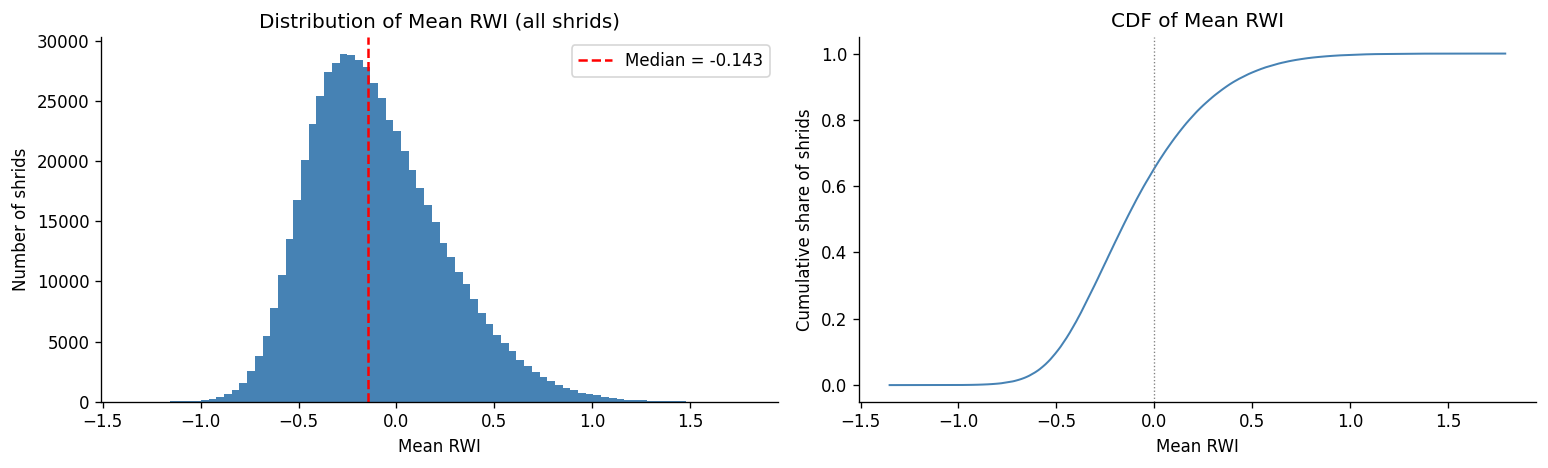

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(rwi['facebook_mean_rwi'].dropna(), bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(rwi['facebook_mean_rwi'].median(), color='red', lw=1.5, linestyle='--', label=f"Median = {rwi['facebook_mean_rwi'].median():.3f}")
axes[0].set_xlabel('Mean RWI')
axes[0].set_ylabel('Number of shrids')
axes[0].set_title('Distribution of Mean RWI (all shrids)')
axes[0].legend()

# CDF
sorted_rwi = np.sort(rwi['facebook_mean_rwi'].dropna())
cdf = np.arange(1, len(sorted_rwi) + 1) / len(sorted_rwi)
axes[1].plot(sorted_rwi, cdf, lw=1.2, color='steelblue')
axes[1].axvline(0, color='grey', lw=0.8, linestyle=':')
axes[1].set_xlabel('Mean RWI')
axes[1].set_ylabel('Cumulative share of shrids')
axes[1].set_title('CDF of Mean RWI')

plt.tight_layout()

fig.savefig(OUTPUT_DIR / "rwi_01_mean_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.2  Spread between min and max RWI within a shrid

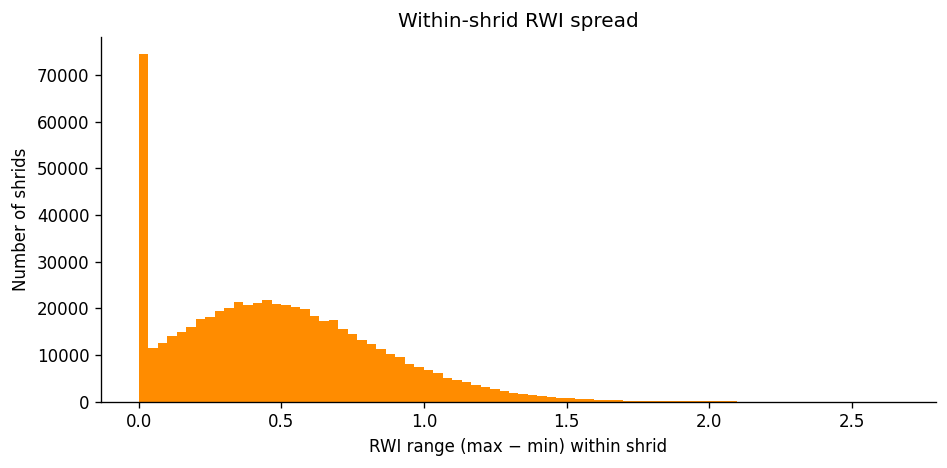

In [5]:
rwi['rwi_range'] = rwi['facebook_max_rwi'] - rwi['facebook_min_rwi']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rwi['rwi_range'].dropna(), bins=80, color='darkorange', edgecolor='none')
ax.set_xlabel('RWI range (max − min) within shrid')
ax.set_ylabel('Number of shrids')
ax.set_title('Within-shrid RWI spread')
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "rwi_02_range.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.3  RWI components: mean, min, max — violin comparison

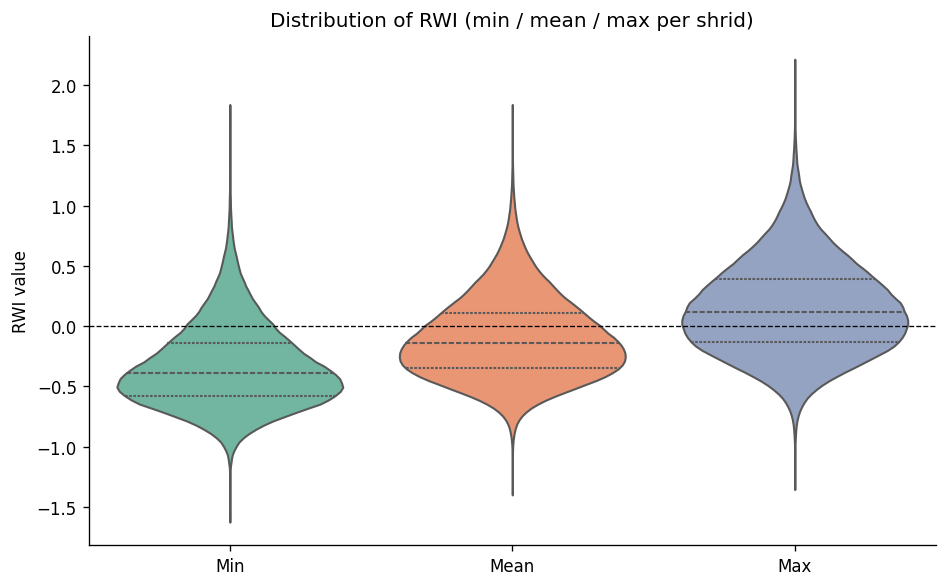

In [6]:
rwi_melt = rwi[['facebook_mean_rwi', 'facebook_min_rwi', 'facebook_max_rwi']].melt(var_name='metric', value_name='value')
label_map = {'facebook_mean_rwi': 'Mean', 'facebook_min_rwi': 'Min', 'facebook_max_rwi': 'Max'}
rwi_melt['metric'] = rwi_melt['metric'].map(label_map)

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=rwi_melt, x='metric', y='value', palette='Set2', ax=ax, inner='quartile', order=['Min','Mean','Max'])
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('')
ax.set_ylabel('RWI value')
ax.set_title('Distribution of RWI (min / mean / max per shrid)')
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "rwi_03_violin.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4  Measurement error: mean error distribution

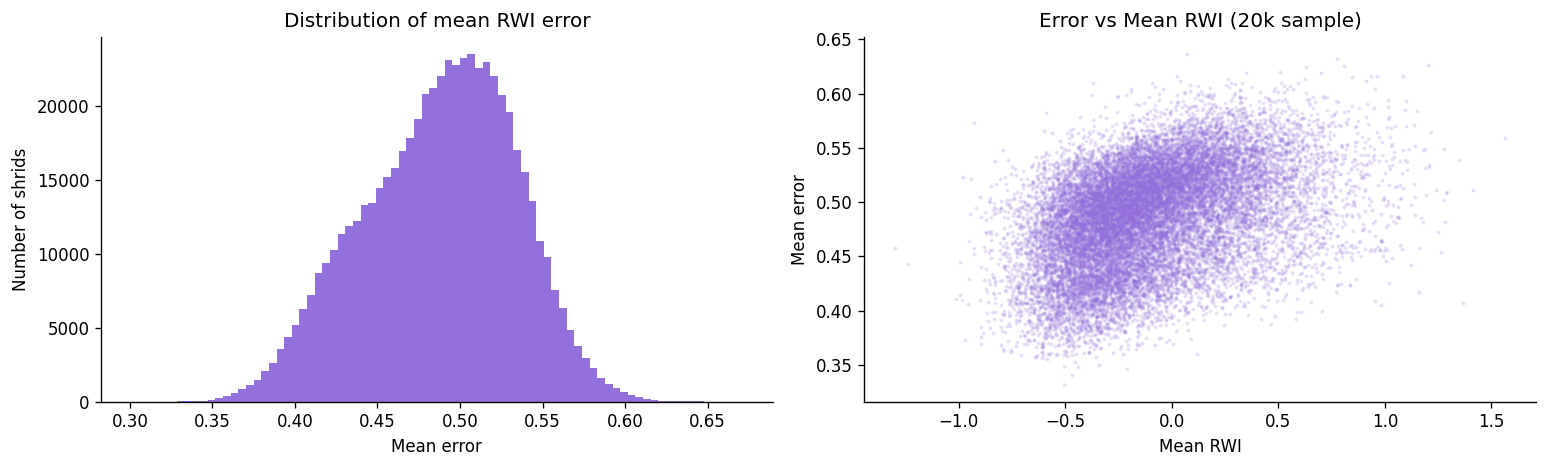

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(rwi['facebook_mean_error'].dropna(), bins=80, color='mediumpurple', edgecolor='none')
axes[0].set_xlabel('Mean error')
axes[0].set_ylabel('Number of shrids')
axes[0].set_title('Distribution of mean RWI error')

# Error vs mean RWI scatter (sample 20k points)
sample = rwi[['facebook_mean_rwi', 'facebook_mean_error']].dropna().sample(min(20_000, len(rwi)), random_state=42)
axes[1].scatter(sample['facebook_mean_rwi'], sample['facebook_mean_error'], alpha=0.15, s=2, color='mediumpurple')
axes[1].set_xlabel('Mean RWI')
axes[1].set_ylabel('Mean error')
axes[1].set_title('Error vs Mean RWI (20k sample)')

plt.tight_layout()

fig.savefig(OUTPUT_DIR / "rwi_04_error.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.5  Number of cells per shrid

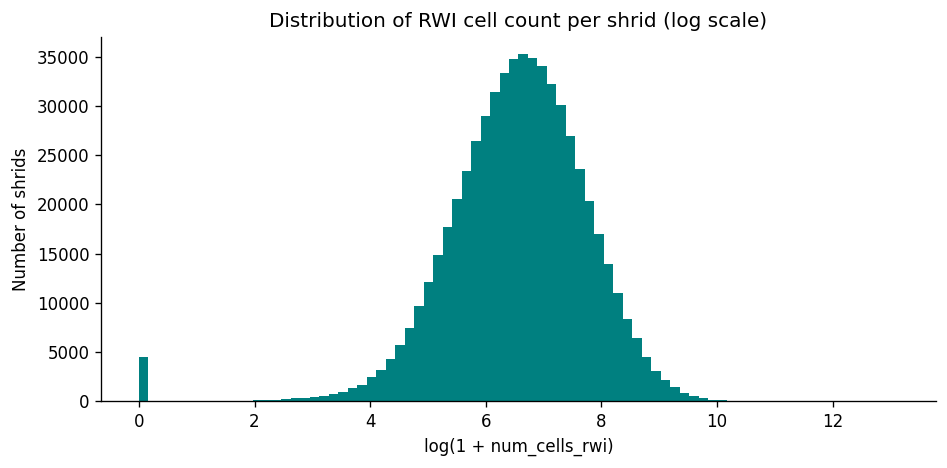

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(rwi['facebook_num_cells_rwi'].dropna()), bins=80, color='teal', edgecolor='none')
ax.set_xlabel('log(1 + num_cells_rwi)')
ax.set_ylabel('Number of shrids')
ax.set_title('Distribution of RWI cell count per shrid (log scale)')
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "rwi_05_num_cells.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2  GHS-POP Rasters (2020 & 2025)
Rasters are ~32k × 32k pixels; we downsample to ~1000 × 1000 for visualisation.

In [9]:
DISPLAY_SIZE = 1200   # pixels per side for visualisation

def load_raster_downsampled(path, size=DISPLAY_SIZE):
    """Read a raster downsampled to `size` × `size`, return array + metadata."""
    with rasterio.open(path) as src:
        scale_x = src.width  / size
        scale_y = src.height / size
        new_w   = int(src.width  / scale_x)
        new_h   = int(src.height / scale_y)
        data = src.read(
            1,
            out_shape=(new_h, new_w),
            resampling=Resampling.average
        ).astype(float)
        # mask nan and zeros for population
        data[~np.isfinite(data)] = np.nan
        bounds = src.bounds
    return data, bounds

pop2020, bounds = load_raster_downsampled(POP_2020)
pop2025, _      = load_raster_downsampled(POP_2025)
print(f'2020 grid: {pop2020.shape}, valid px: {np.sum(pop2020 > 0):,}')
print(f'2025 grid: {pop2025.shape}, valid px: {np.sum(pop2025 > 0):,}')

2020 grid: (1200, 1200), valid px: 417,537
2025 grid: (1200, 1200), valid px: 417,644


### 2.1  Population maps — 2020 and 2025

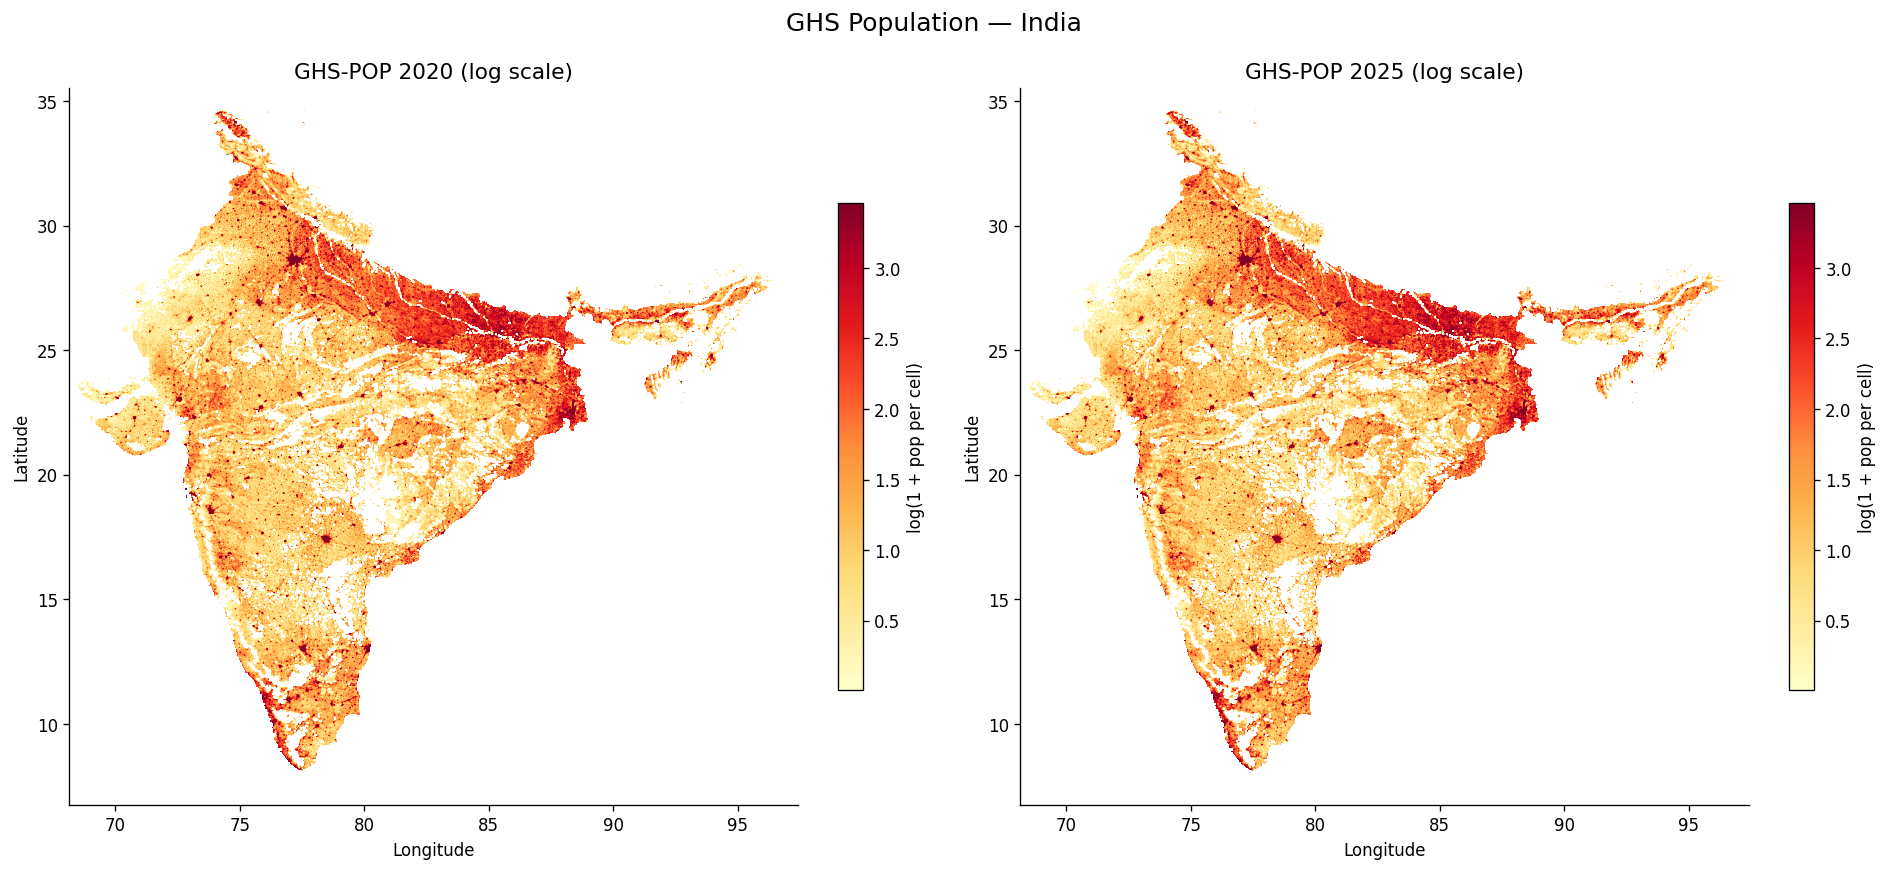

In [10]:
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Use log scale for population density
def log_pop(arr):
    out = np.full_like(arr, np.nan)
    mask = arr > 0
    out[mask] = np.log1p(arr[mask])
    return out

vmin = np.nanpercentile(log_pop(pop2020), 2)
vmax = np.nanpercentile(log_pop(pop2020), 98)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, arr, yr in zip(axes, [pop2020, pop2025], [2020, 2025]):
    im = ax.imshow(
        log_pop(arr),
        extent=extent, origin='upper',
        cmap='YlOrRd', vmin=vmin, vmax=vmax
    )
    ax.set_title(f'GHS-POP {yr} (log scale)', fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, label='log(1 + pop per cell)', fraction=0.03)

plt.suptitle('GHS Population — India', fontsize=15, y=1.01)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "pop_01_maps_2020_2025.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2  Population change 2020 → 2025 (absolute)

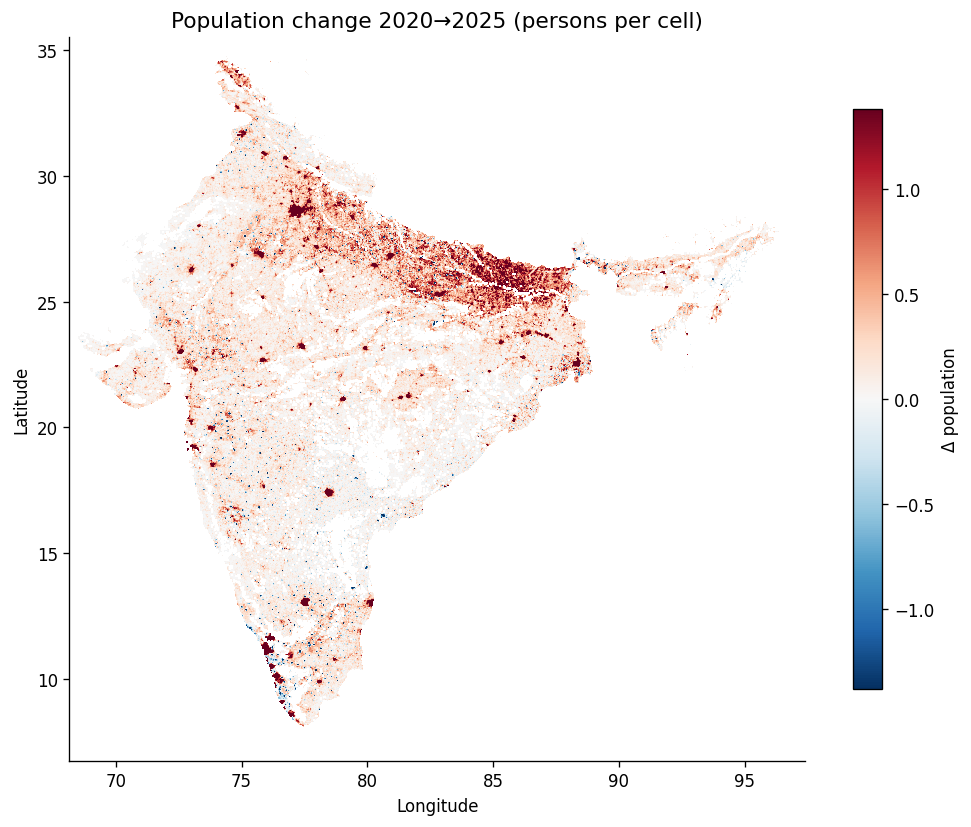

In [11]:
pop_diff = pop2025 - pop2020
# mask cells that are 0 in both years
both_zero = (pop2020 <= 0) & (pop2025 <= 0)
pop_diff[both_zero] = np.nan

abs_lim = np.nanpercentile(np.abs(pop_diff[np.isfinite(pop_diff)]), 97)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(
    pop_diff, extent=extent, origin='upper',
    cmap='RdBu_r', vmin=-abs_lim, vmax=abs_lim
)
ax.set_title('Population change 2020→2025 (persons per cell)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(im, ax=ax, label='Δ population', fraction=0.03)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "pop_02_change_absolute.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3  Population change — percentage

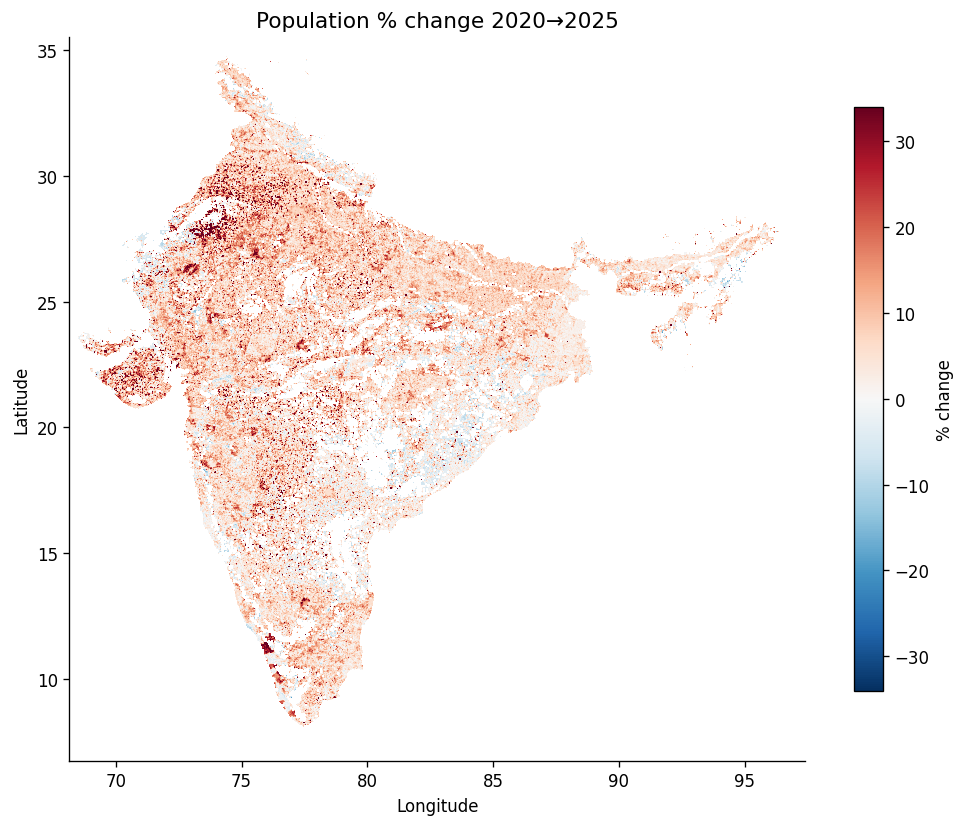

In [12]:
pop_pct = np.full_like(pop2020, np.nan)
valid = (pop2020 > 0) & (pop2025 > 0)
pop_pct[valid] = (pop2025[valid] - pop2020[valid]) / pop2020[valid] * 100

pct_lim = np.nanpercentile(np.abs(pop_pct[np.isfinite(pop_pct)]), 97)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(
    pop_pct, extent=extent, origin='upper',
    cmap='RdBu_r', vmin=-pct_lim, vmax=pct_lim
)
ax.set_title('Population % change 2020→2025', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(im, ax=ax, label='% change', fraction=0.03)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "pop_03_change_pct.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4  Pixel-level population distributions

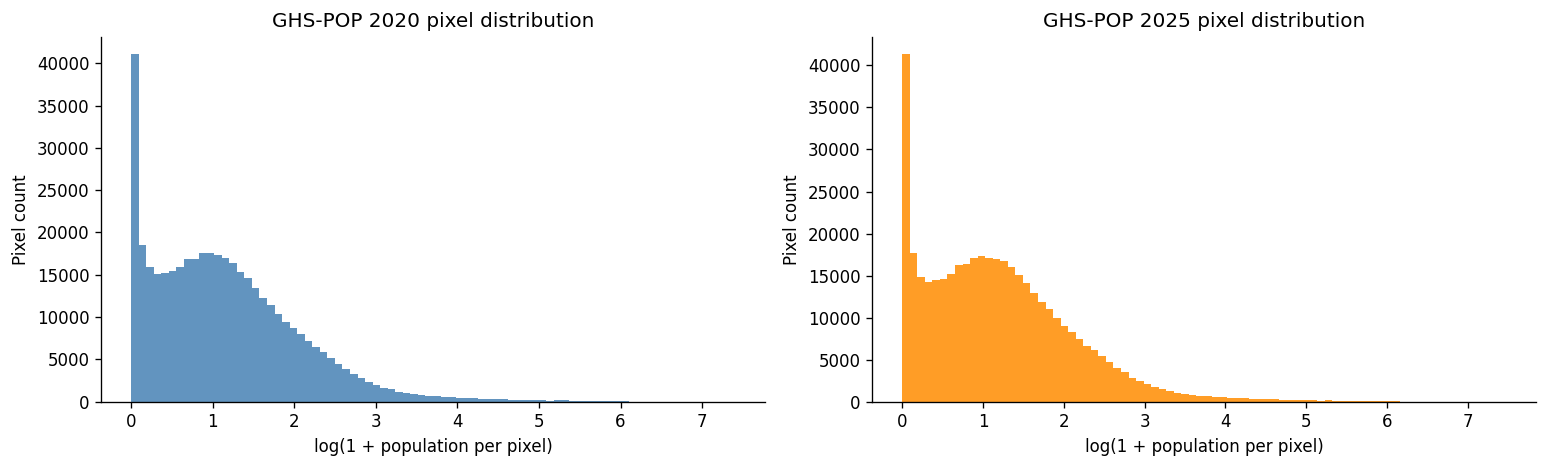

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, arr, yr, col in zip(axes, [pop2020, pop2025], [2020, 2025], ['steelblue', 'darkorange']):
    vals = arr[arr > 0].flatten()
    ax.hist(np.log1p(vals), bins=80, color=col, edgecolor='none', alpha=0.85)
    ax.set_xlabel('log(1 + population per pixel)')
    ax.set_ylabel('Pixel count')
    ax.set_title(f'GHS-POP {yr} pixel distribution')

plt.tight_layout()

fig.savefig(OUTPUT_DIR / "pop_04_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.5  Overlay comparison — 2020 vs 2025 histogram

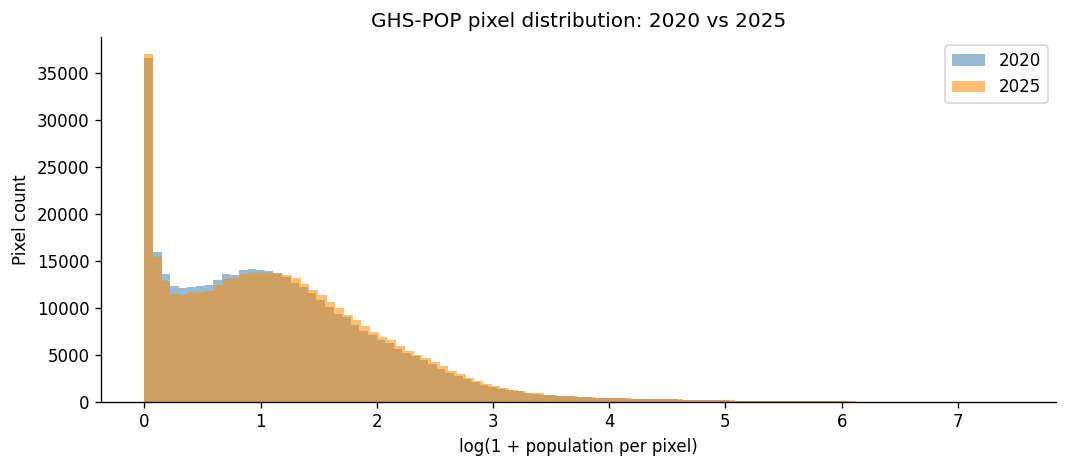

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
for arr, yr, col in [(pop2020, 2020, 'steelblue'), (pop2025, 2025, 'darkorange')]:
    vals = arr[arr > 0].flatten()
    ax.hist(np.log1p(vals), bins=100, alpha=0.55, color=col, label=str(yr), edgecolor='none')

ax.set_xlabel('log(1 + population per pixel)')
ax.set_ylabel('Pixel count')
ax.set_title('GHS-POP pixel distribution: 2020 vs 2025')
ax.legend()
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "pop_05_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.6  Summary statistics

In [15]:
rows = []
for arr, yr in [(pop2020, 2020), (pop2025, 2025)]:
    vals = arr[arr > 0].flatten()
    rows.append({
        'Year': yr,
        'Populated pixels': f'{len(vals):,}',
        'Total population (M)': f"{vals.sum() / 1e6:.1f}",
        'Mean pop/pixel': f'{vals.mean():.1f}',
        'Median pop/pixel': f'{np.median(vals):.2f}',
        'Max pop/pixel': f'{vals.max():.0f}',
    })

pd.DataFrame(rows).set_index('Year')

,Populated pixels,Total population (M),Mean pop/pixel,Median pop/pixel,Max pop/pixel
Year,,,,,
2020,"417,537",2.1,4.9,1.81,1636
2025,"417,644",2.1,5.1,1.94,1755


---
## 3  GHS Built-up Surface (2020 & 2025)
Values are m² of built-up surface per 100m cell (0–10 000). Rasters are downsampled to ~1200×1200 for display.

In [16]:
BUILT_2020 = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/data/GHS_BUILT_S_2020_India_clean.tif")
BUILT_2025 = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/data/GHS_BUILT_S_2025_India_clean.tif")

blt2020, blt_bounds = load_raster_downsampled(BUILT_2020)
blt2025, _          = load_raster_downsampled(BUILT_2025)

# zero-fill nodata (0 = no built-up)
blt2020 = np.where(blt2020 < 0, 0, blt2020)
blt2025 = np.where(blt2025 < 0, 0, blt2025)

print(f"2020 — built-up pixels (>0): {np.sum(blt2020 > 0):,}  max: {blt2020.max():.0f} m²")
print(f"2025 — built-up pixels (>0): {np.sum(blt2025 > 0):,}  max: {blt2025.max():.0f} m²")

2020 — built-up pixels (>0): 408,697  max: 5975 m²
2025 — built-up pixels (>0): 409,028  max: 5975 m²


### 3.1  Built-up surface maps — 2020 and 2025

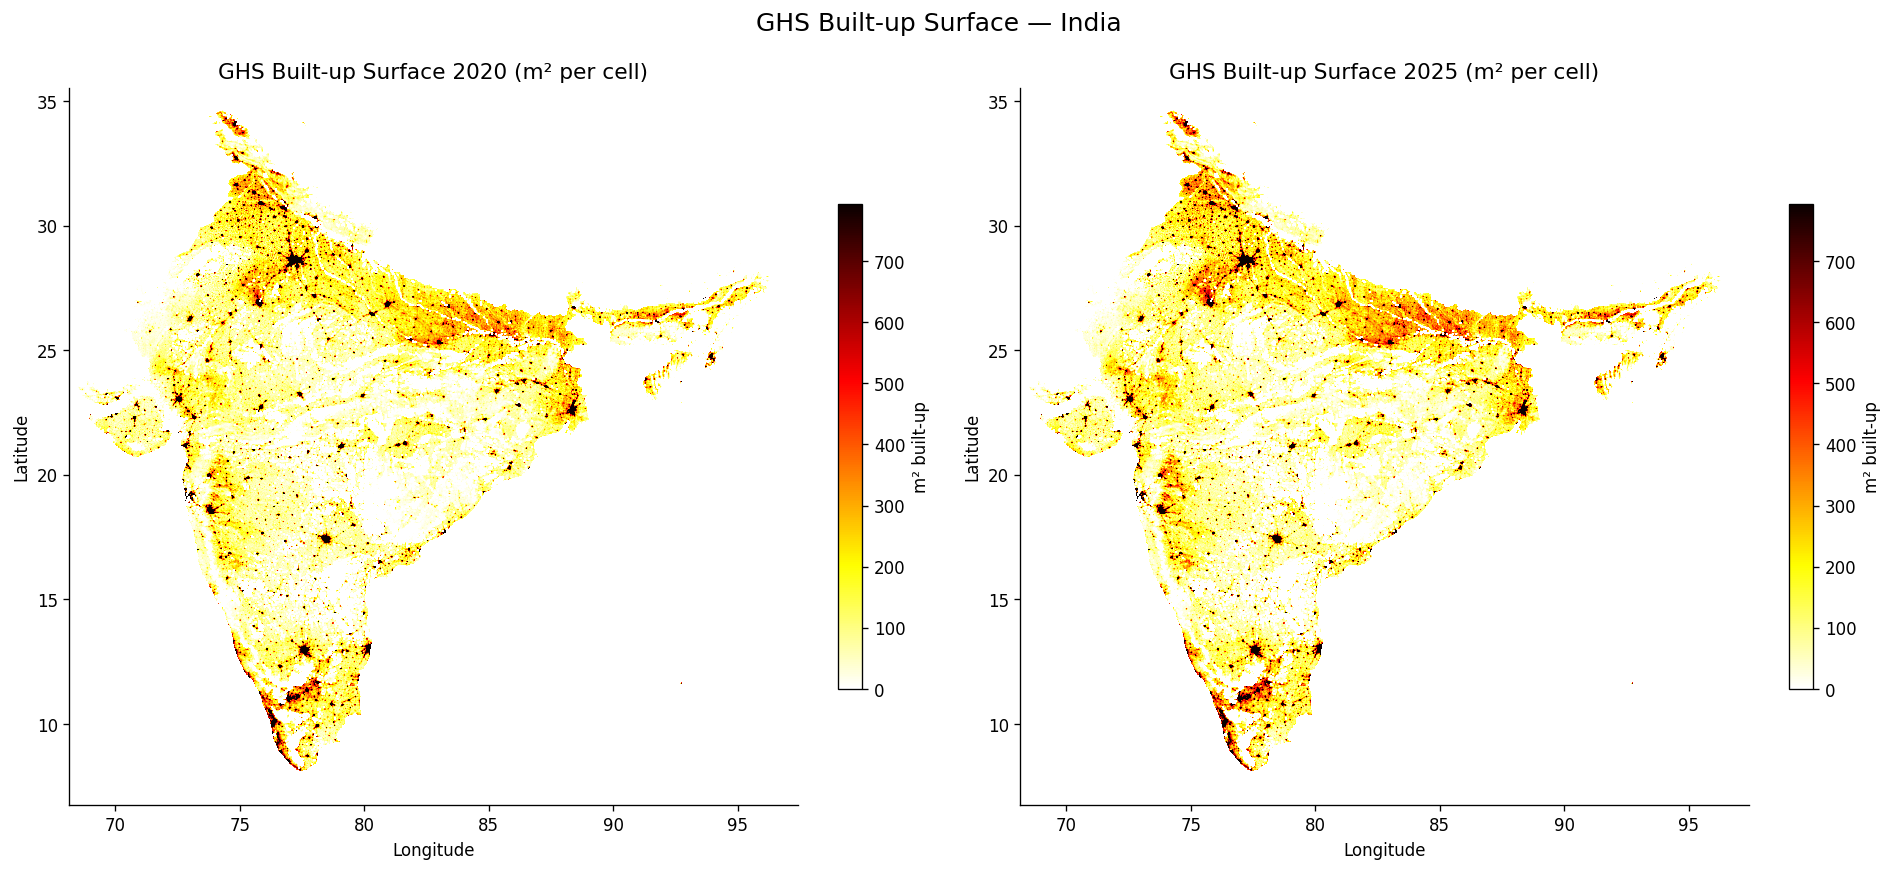

In [17]:
blt_extent = [blt_bounds.left, blt_bounds.right, blt_bounds.bottom, blt_bounds.top]
vmax_blt = np.nanpercentile(blt2020[blt2020 > 0], 98)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, arr, yr in zip(axes, [blt2020, blt2025], [2020, 2025]):
    disp = np.where(arr > 0, arr, np.nan)
    im = ax.imshow(disp, extent=blt_extent, origin="upper",
                   cmap="hot_r", vmin=0, vmax=vmax_blt)
    ax.set_title(f"GHS Built-up Surface {yr} (m² per cell)", fontsize=13)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax, label="m² built-up", fraction=0.03)

plt.suptitle("GHS Built-up Surface — India", fontsize=15, y=1.01)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "blt_01_maps_2020_2025.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2  Built-up change 2020 → 2025 (absolute, m²)

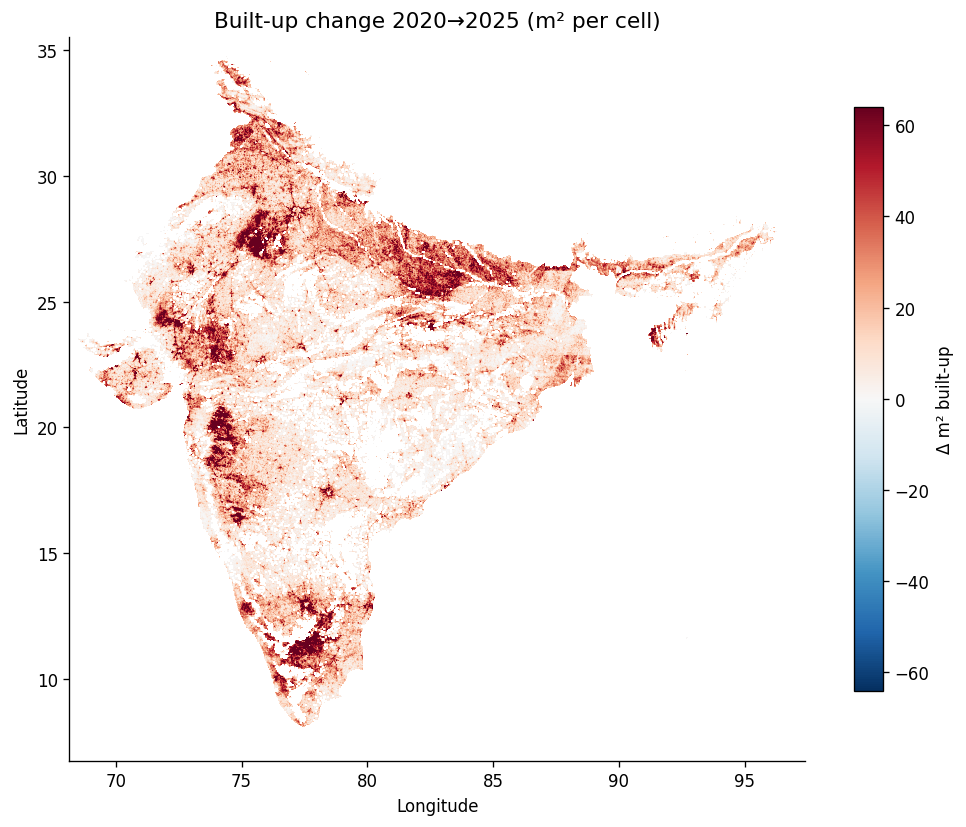

In [18]:
blt_diff = blt2025 - blt2020
blt_diff[((blt2020 == 0) & (blt2025 == 0))] = np.nan

abs_lim_blt = np.nanpercentile(np.abs(blt_diff[np.isfinite(blt_diff)]), 97)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(blt_diff, extent=blt_extent, origin="upper",
               cmap="RdBu_r", vmin=-abs_lim_blt, vmax=abs_lim_blt)
ax.set_title("Built-up change 2020→2025 (m² per cell)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, label="Δ m² built-up", fraction=0.03)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "blt_02_change_absolute.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3  Built-up change — percentage

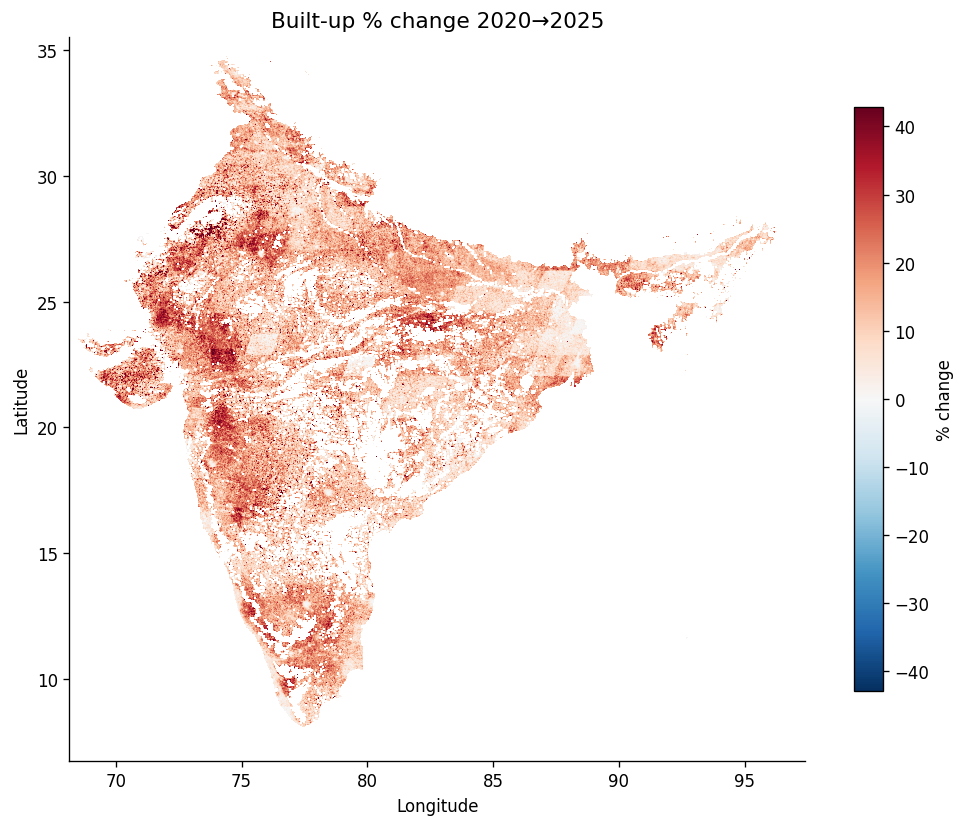

In [19]:
blt_pct = np.full_like(blt2020, np.nan)
valid_blt = (blt2020 > 0) & (blt2025 > 0)
blt_pct[valid_blt] = (blt2025[valid_blt] - blt2020[valid_blt]) / blt2020[valid_blt] * 100

pct_lim_blt = np.nanpercentile(np.abs(blt_pct[np.isfinite(blt_pct)]), 97)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(blt_pct, extent=blt_extent, origin="upper",
               cmap="RdBu_r", vmin=-pct_lim_blt, vmax=pct_lim_blt)
ax.set_title("Built-up % change 2020→2025", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, label="% change", fraction=0.03)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "blt_03_change_pct.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.4  Distribution of built-up surface values

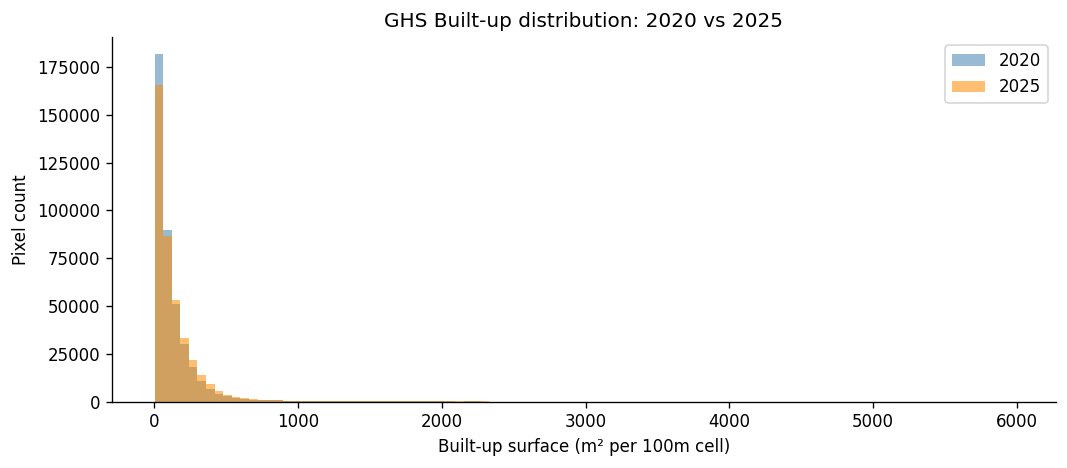

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
for arr, yr, col in [(blt2020, 2020, "steelblue"), (blt2025, 2025, "darkorange")]:
    vals = arr[arr > 0].flatten()
    ax.hist(vals, bins=100, alpha=0.55, color=col, label=str(yr), edgecolor="none")

ax.set_xlabel("Built-up surface (m² per 100m cell)")
ax.set_ylabel("Pixel count")
ax.set_title("GHS Built-up distribution: 2020 vs 2025")
ax.legend()
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "blt_04_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5  Summary statistics

In [21]:
rows_blt = []
for arr, yr in [(blt2020, 2020), (blt2025, 2025)]:
    vals = arr[arr > 0].flatten()
    rows_blt.append({
        "Year": yr,
        "Built-up pixels": f"{len(vals):,}",
        "Total built-up (km²)": f"{vals.sum() / 1e6:.1f}",
        "Mean m²/pixel": f"{vals.mean():.1f}",
        "Median m²/pixel": f"{np.median(vals):.0f}",
        "Max m²/pixel": f"{vals.max():.0f}",
    })

pd.DataFrame(rows_blt).set_index("Year")

,Built-up pixels,Total built-up (km²),Mean m²/pixel,Median m²/pixel,Max m²/pixel
Year,,,,,
2020,"408,697",57.6,140.9,73,5975
2025,"409,028",63.9,156.2,84,5975


## 4 Village polygon shapefile and SHRID ID

In [22]:
import geopandas as gpd
import pandas as pd

villages = gpd.read_file('/Users/payelmallick/Documents/Top_economic_centre_assessment/data/shrug-pc11-village-poly-gpkg/village_modified.gpkg')
rwi = pd.read_stata('/Users/payelmallick/Documents/Top_economic_centre_assessment/data/shrug-facebook-rwi-dta/facebook_rwi_shrid.dta')

# See all columns in both
print("GPKG columns:", villages.columns.tolist())
print("RWI columns:", rwi.columns.tolist())

# See first row of each
print("\nGPKG first row:")
print(villages.iloc[0])

print("\nRWI first row:")
print(rwi.iloc[0])

GPKG columns: ['pc11_state_id', 'pc11_district_id', 'pc11_subdistrict_id', 'pc11_town_village_id', 'town_village_name', 'mdds_og', 'geometry']
RWI columns: ['shrid2', 'facebook_mean_rwi', 'facebook_min_rwi', 'facebook_max_rwi', 'facebook_num_cells_rwi', 'facebook_mean_error', 'facebook_min_error', 'facebook_max_error', 'facebook_num_cells_error']

GPKG first row:
pc11_state_id                                                          01
pc11_district_id                                                      000
pc11_subdistrict_id                                                 00000
pc11_town_village_id                                               000000
town_village_name                                                    None
mdds_og                                                                 0
geometry                MULTIPOLYGON (((77.9654539102614 35.4933124700...
Name: 0, dtype: object

RWI first row:
shrid2                      11-01-001-00001-000001
facebook_mean_rwi         

---
## 4  Village-level RWI map
Join Facebook RWI onto PC11 village polygons via a constructed  key.

In [23]:
import geopandas as gpd

VILLAGE_PATH = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/data/shrug-pc11-village-poly-gpkg/village_modified.gpkg")

villages = gpd.read_file(VILLAGE_PATH)

villages["shrid2"] = (
    "11-" +
    villages["pc11_state_id"] + "-" +
    villages["pc11_district_id"] + "-" +
    villages["pc11_subdistrict_id"] + "-" +
    villages["pc11_town_village_id"]
)

villages = villages.merge(rwi[["shrid2", "facebook_mean_rwi"]], on="shrid2", how="left")

matched = villages["facebook_mean_rwi"].notna().sum()
print(f"Villages: {len(villages):,}  |  matched to RWI: {matched:,}  ({matched/len(villages)*100:.1f}%)")
villages[["town_village_name", "shrid2", "facebook_mean_rwi"]].head(10)

Villages: 648,878  |  matched to RWI: 591,009  (91.1%)


,town_village_name,shrid2,facebook_mean_rwi
0,None,11-01-000-00000-000000,NaN
1,Bore,11-01-001-00001-000001,-0.522531
2,Keran,11-01-001-00001-000002,-0.329810
3,Bugna,11-01-001-00001-000003,NaN
4,Bichwal,11-01-001-00001-000004,NaN
5,Mindiyan,11-01-001-00001-000005,NaN
6,Patrin,11-01-001-00001-000006,-0.136000
7,Juma Gund,11-01-001-00001-000007,-0.104848
8,Khantha Wali (Shalun Bhatta),11-01-001-00001-000008,0.327000
9,Har Duing,11-01-001-00001-000009,0.083590


### 4.1  Choropleth map of mean RWI by village

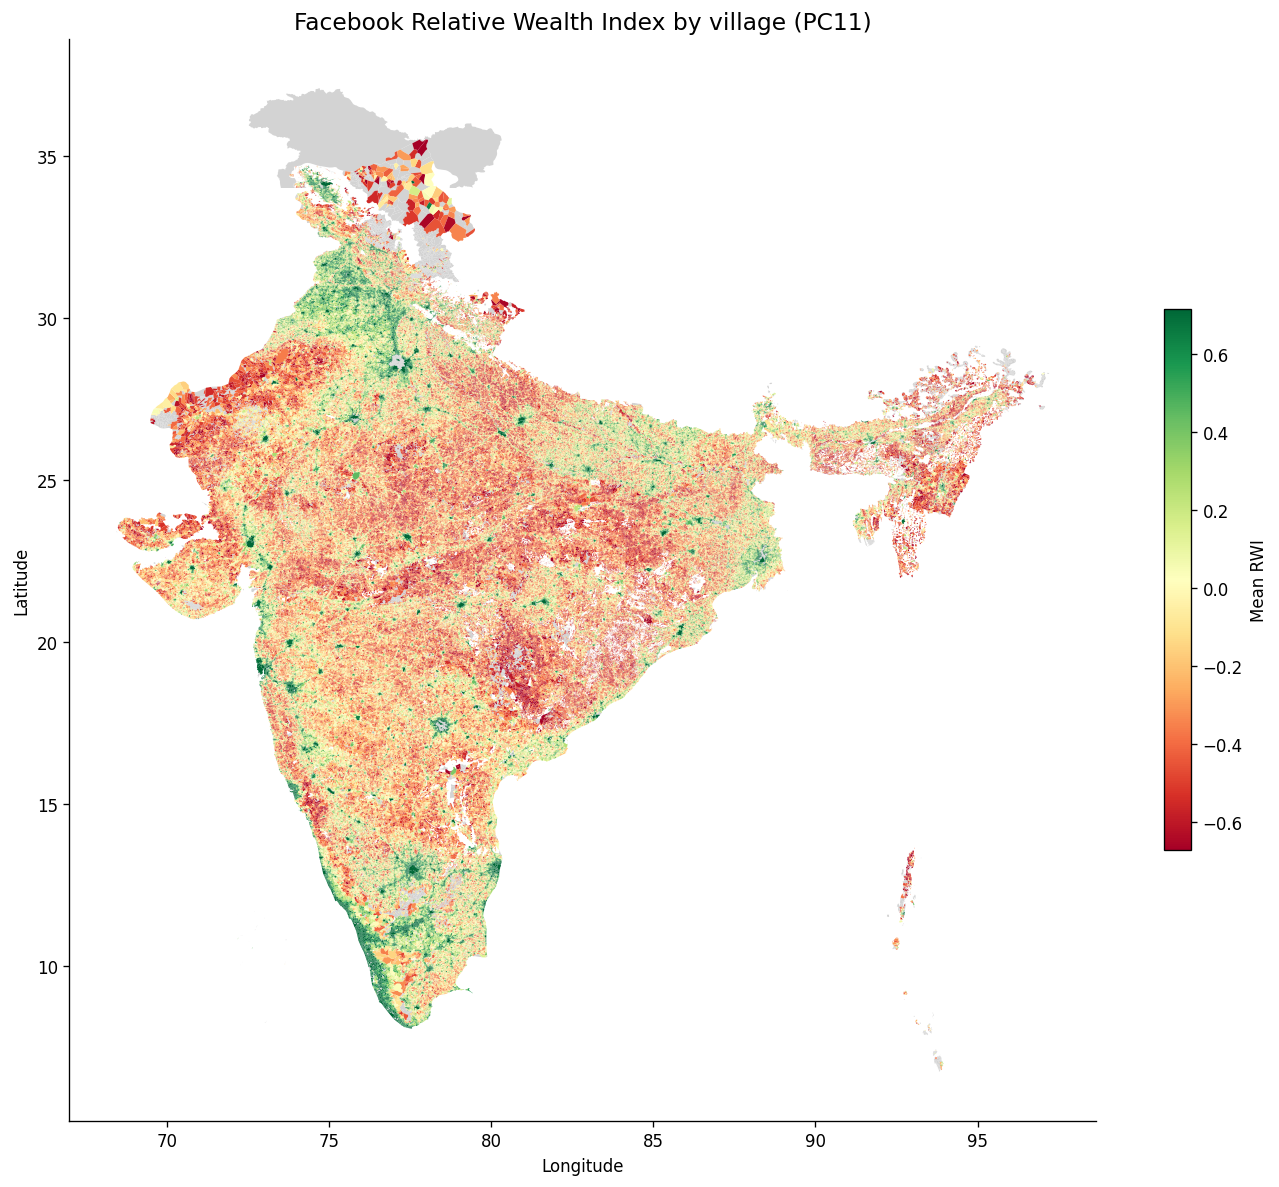

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))

villages[villages["facebook_mean_rwi"].isna()].plot(
    ax=ax, color="lightgrey", linewidth=0, label="No data"
)
villages[villages["facebook_mean_rwi"].notna()].plot(
    column="facebook_mean_rwi",
    ax=ax,
    cmap="RdYlGn",
    linewidth=0,
    legend=True,
    legend_kwds={"label": "Mean RWI", "orientation": "vertical", "shrink": 0.5},
    vmin=villages["facebook_mean_rwi"].quantile(0.02),
    vmax=villages["facebook_mean_rwi"].quantile(0.98),
)

ax.set_title("Facebook Relative Wealth Index by village (PC11)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "village_01_rwi_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2  RWI distribution across matched villages

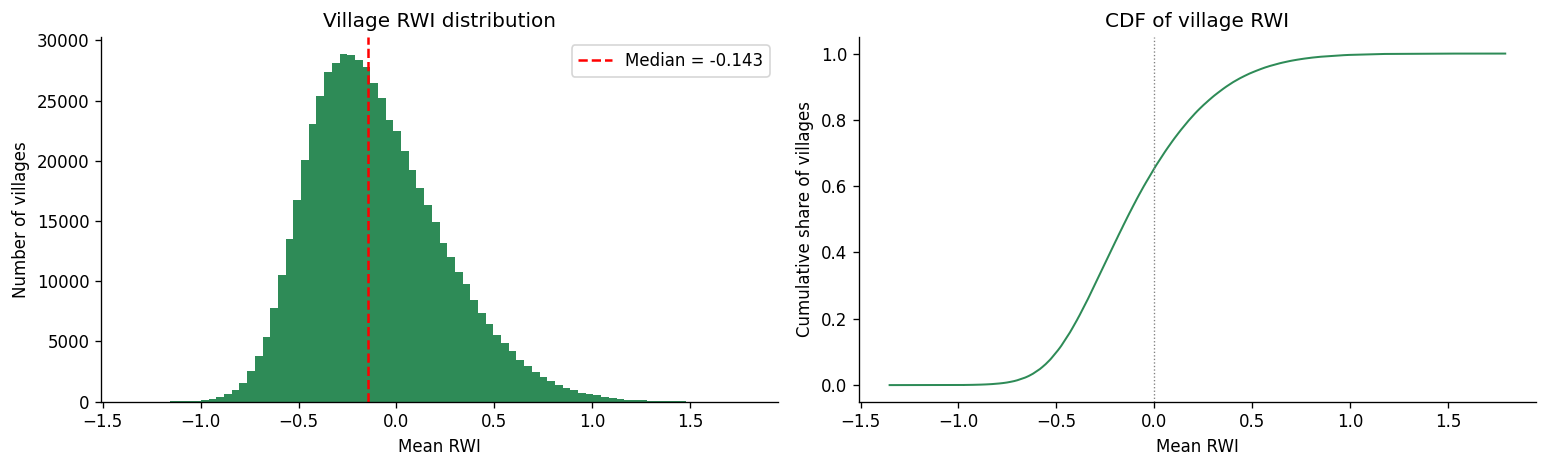

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vals = villages["facebook_mean_rwi"].dropna()

axes[0].hist(vals, bins=80, color="seagreen", edgecolor="none")
axes[0].axvline(vals.median(), color="red", lw=1.5, linestyle="--",
                label=f"Median = {vals.median():.3f}")
axes[0].set_xlabel("Mean RWI")
axes[0].set_ylabel("Number of villages")
axes[0].set_title("Village RWI distribution")
axes[0].legend()

sorted_vals = np.sort(vals)
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color="seagreen", lw=1.2)
axes[1].axvline(0, color="grey", lw=0.8, linestyle=":")
axes[1].set_xlabel("Mean RWI")
axes[1].set_ylabel("Cumulative share of villages")
axes[1].set_title("CDF of village RWI")

plt.tight_layout()

fig.savefig(OUTPUT_DIR / "village_02_rwi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5  VIIRS Night-time Lights (2021 & 2025)
Raster maps from GEE exports. Tabular shrid-level data available 2012–2023; EDA uses 2021 (overlapping with raster years).

In [26]:
VIIRS_2021 = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/data/VIIRS/VIIRS_NTL_2021_India.tif")
VIIRS_2025 = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/data/VIIRS/VIIRS_NTL_2025_India.tif")
VIIRS_TAB  = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/shrug-viirs-annual-dta/viirs_annual_shrid.dta")

ntl2021, ntl_bounds = load_raster_downsampled(VIIRS_2021)
ntl2025, _          = load_raster_downsampled(VIIRS_2025)

ntl2021 = np.clip(ntl2021, 0, None)
ntl2025 = np.clip(ntl2025, 0, None)

print(f"2021 — lit pixels (>0): {np.sum(ntl2021>0):,}  max radiance: {np.nanmax(ntl2021):.1f}")
print(f"2025 — lit pixels (>0): {np.sum(ntl2025>0):,}  max radiance: {np.nanmax(ntl2025):.1f}")

2021 — lit pixels (>0): 472,614  max radiance: 104.6
2025 — lit pixels (>0): 472,612  max radiance: 126.1


### 5.1  Night-time lights maps — 2021 and 2025

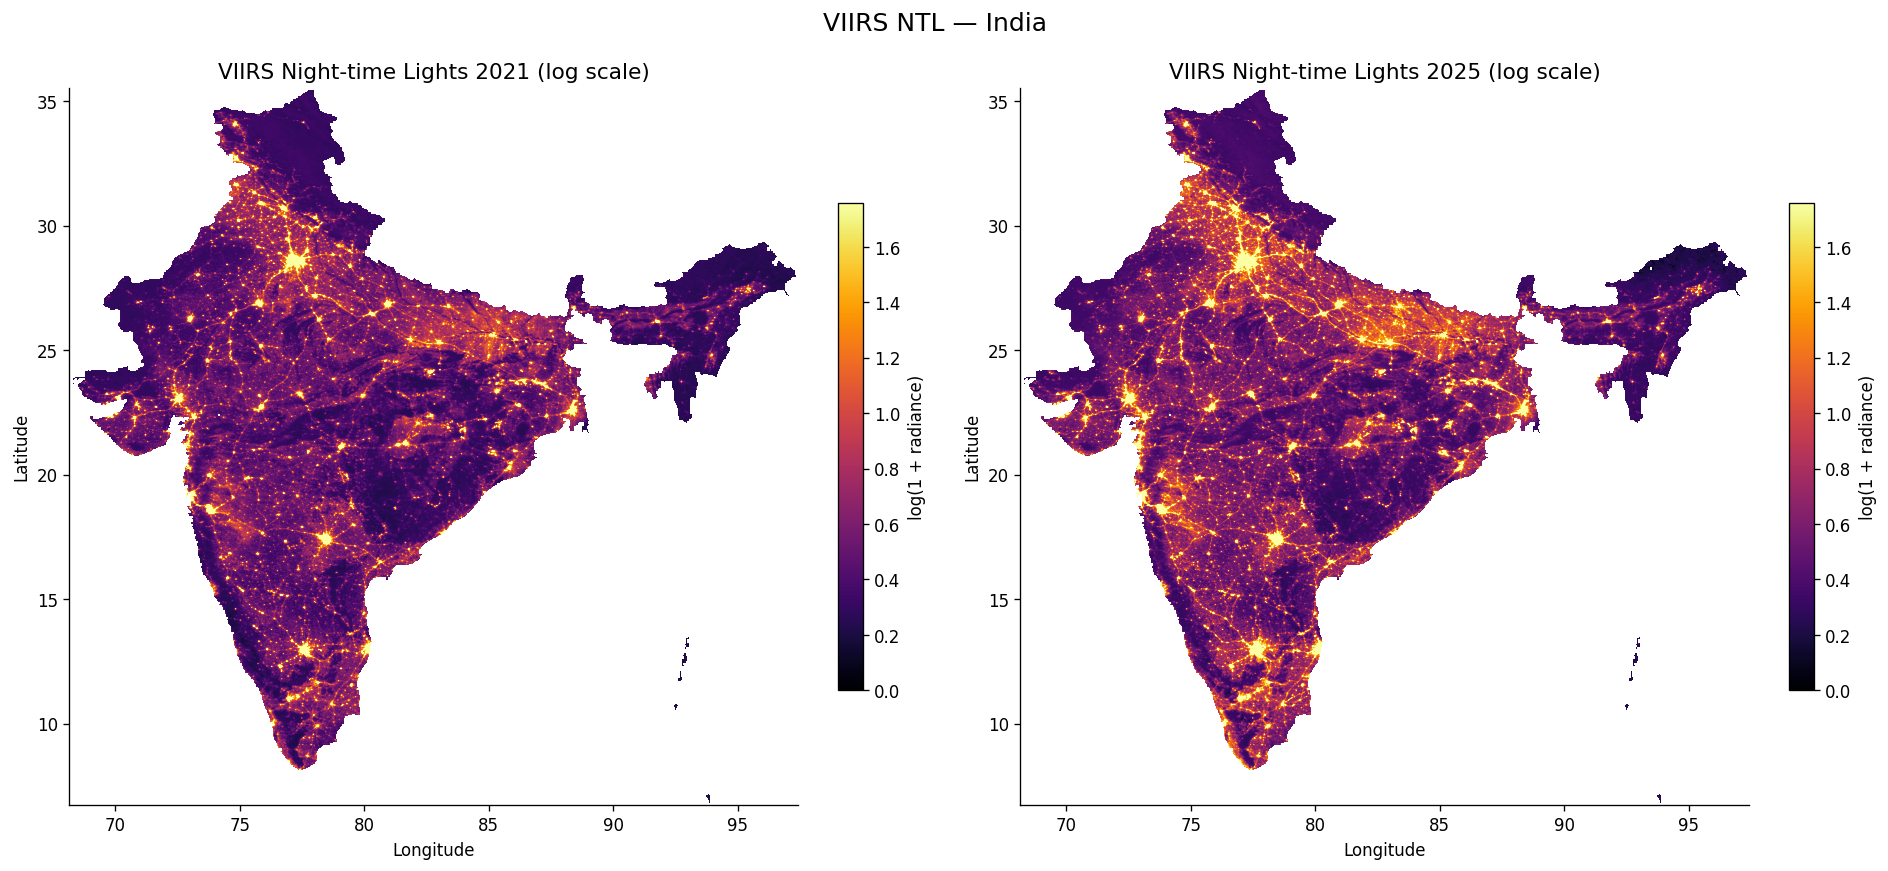

In [27]:
ntl_extent = [ntl_bounds.left, ntl_bounds.right, ntl_bounds.bottom, ntl_bounds.top]

def log_ntl(arr):
    out = np.full_like(arr, np.nan)
    out[arr > 0] = np.log1p(arr[arr > 0])
    return out

vmax_ntl = np.nanpercentile(log_ntl(ntl2021)[log_ntl(ntl2021) > 0], 98)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, arr, yr in zip(axes, [ntl2021, ntl2025], [2021, 2025]):
    disp = log_ntl(arr)
    disp[arr == 0] = np.nan
    im = ax.imshow(disp, extent=ntl_extent, origin="upper",
                   cmap="inferno", vmin=0, vmax=vmax_ntl)
    ax.set_title(f"VIIRS Night-time Lights {yr} (log scale)", fontsize=13)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax, label="log(1 + radiance)", fraction=0.03)

plt.suptitle("VIIRS NTL — India", fontsize=15, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ntl_01_maps_2021_2025.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2  Change in night-time lights 2021 → 2025 (absolute)

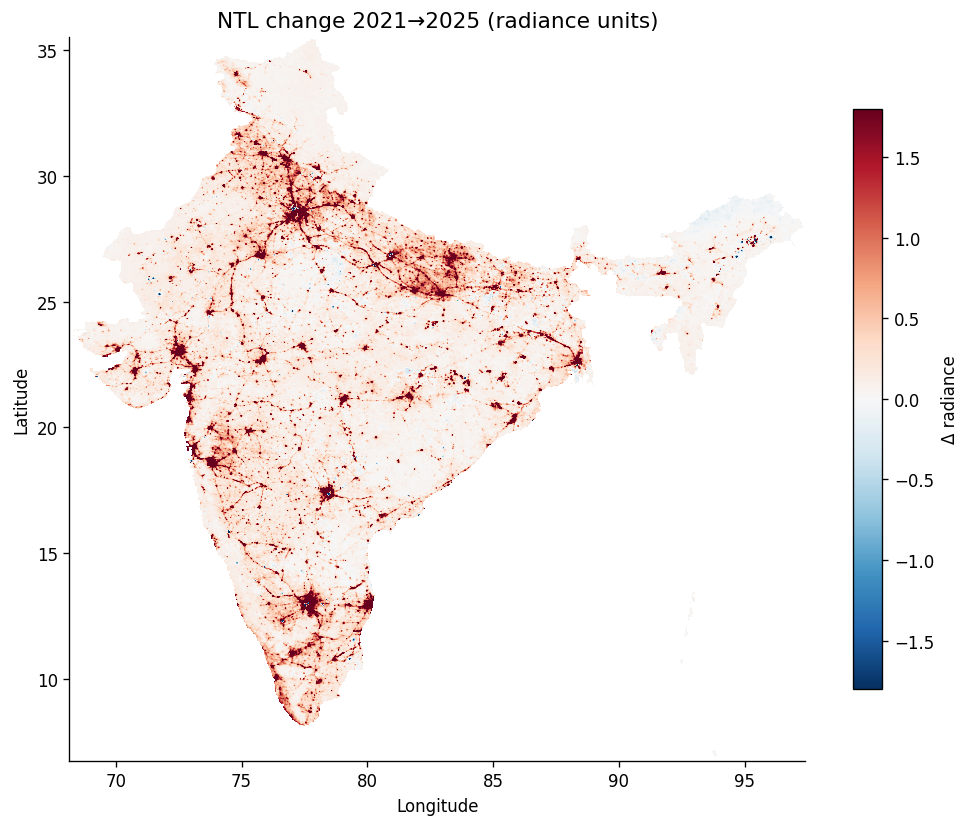

In [28]:
ntl_diff = ntl2025 - ntl2021
ntl_diff[((ntl2021 == 0) & (ntl2025 == 0))] = np.nan

lim_ntl = np.nanpercentile(np.abs(ntl_diff[np.isfinite(ntl_diff)]), 97)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(ntl_diff, extent=ntl_extent, origin="upper",
               cmap="RdBu_r", vmin=-lim_ntl, vmax=lim_ntl)
ax.set_title("NTL change 2021→2025 (radiance units)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, label="Δ radiance", fraction=0.03)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ntl_02_change_absolute.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3  Change in night-time lights 2021 → 2025 (%)

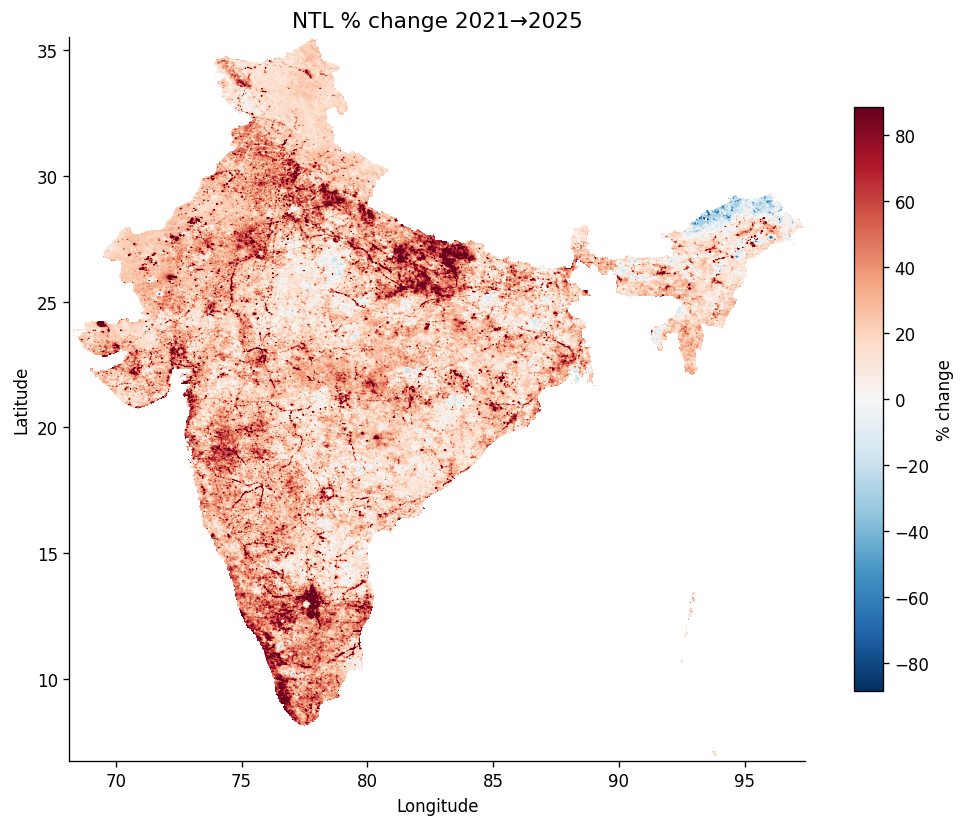

In [29]:
ntl_pct = np.full_like(ntl2021, np.nan)
valid_ntl = (ntl2021 > 0) & (ntl2025 > 0)
ntl_pct[valid_ntl] = (ntl2025[valid_ntl] - ntl2021[valid_ntl]) / ntl2021[valid_ntl] * 100

pct_lim_ntl = np.nanpercentile(np.abs(ntl_pct[np.isfinite(ntl_pct)]), 97)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(ntl_pct, extent=ntl_extent, origin="upper",
               cmap="RdBu_r", vmin=-pct_lim_ntl, vmax=pct_lim_ntl)
ax.set_title("NTL % change 2021→2025", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, label="% change", fraction=0.03)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ntl_03_change_pct.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4  Tabular EDA — shrid-level VIIRS 2021
*Tabular data covers 2012–2023; 2021 selected to align with raster.*

In [30]:
viirs_tab = pd.read_stata(VIIRS_TAB)
v21 = viirs_tab[(viirs_tab["year"] == 2021) & (viirs_tab["category"] == "median-masked")].copy()
print(f"Shrids in 2021 tabular: {len(v21):,}")
v21[["viirs_annual_mean", "viirs_annual_sum", "viirs_annual_max", "viirs_annual_num_cells"]].describe()

Shrids in 2021 tabular: 596,173


,viirs_annual_mean,viirs_annual_sum,viirs_annual_max,viirs_annual_num_cells
count,596173.000000,596173.000000,596173.000000,596173.000000
mean,0.929688,20.660980,2.065722,24.174877
std,1.698185,398.902590,5.394611,162.260838
min,0.000000,0.000000,0.000000,0.005616
25%,0.197612,1.823740,0.788860,5.692904
50%,0.628070,6.678599,1.260285,12.194351
75%,1.149672,16.502994,2.017373,25.884696
max,305.974622,193055.837499,961.494629,78842.569707


### 5.5  Distribution of mean NTL across shrids (2021)

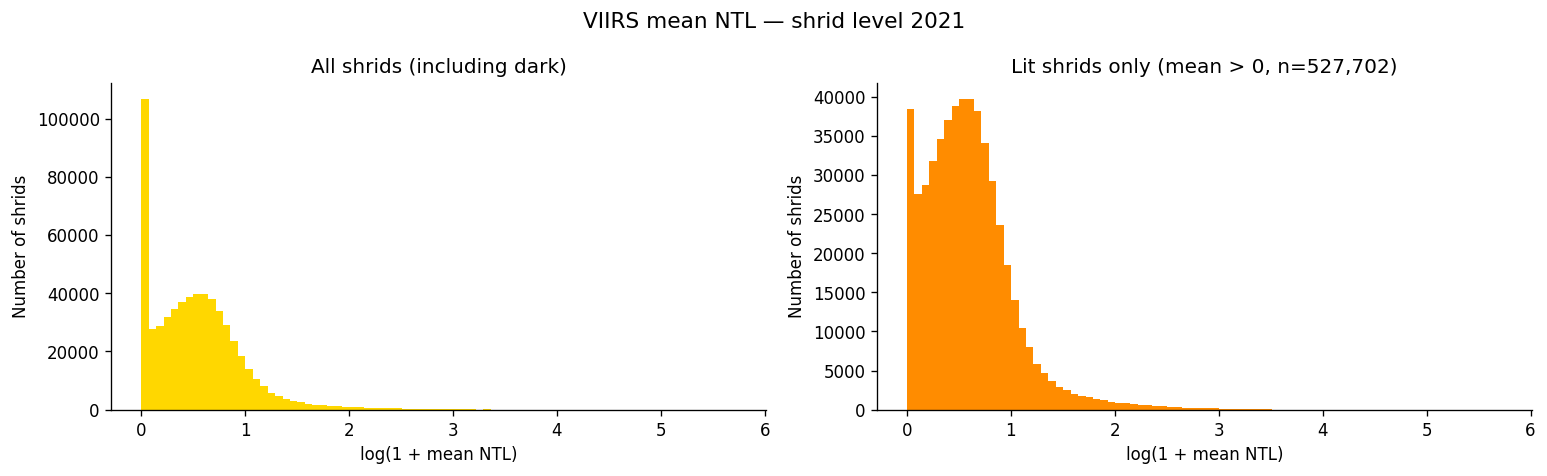

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lit = v21[v21["viirs_annual_mean"] > 0]["viirs_annual_mean"]

axes[0].hist(np.log1p(v21["viirs_annual_mean"]), bins=80,
             color="gold", edgecolor="none")
axes[0].set_xlabel("log(1 + mean NTL)")
axes[0].set_ylabel("Number of shrids")
axes[0].set_title("All shrids (including dark)")

axes[1].hist(np.log1p(lit), bins=80, color="darkorange", edgecolor="none")
axes[1].set_xlabel("log(1 + mean NTL)")
axes[1].set_ylabel("Number of shrids")
axes[1].set_title(f"Lit shrids only (mean > 0, n={len(lit):,})")

plt.suptitle("VIIRS mean NTL — shrid level 2021", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ntl_04_shrid_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.6  CDF and sum NTL vs shrid size

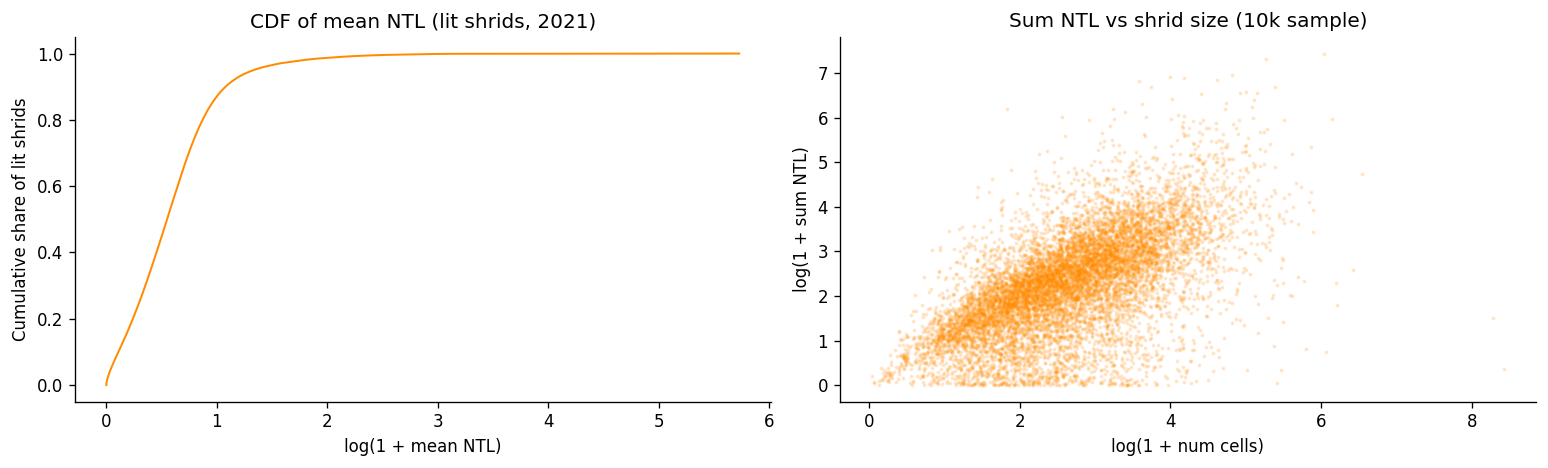

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sv = np.sort(lit)
cdf = np.arange(1, len(sv)+1) / len(sv)
axes[0].plot(np.log1p(sv), cdf, color="darkorange", lw=1.2)
axes[0].set_xlabel("log(1 + mean NTL)")
axes[0].set_ylabel("Cumulative share of lit shrids")
axes[0].set_title("CDF of mean NTL (lit shrids, 2021)")

samp = v21[v21["viirs_annual_mean"] > 0].sample(min(10_000, len(v21)), random_state=42)
axes[1].scatter(np.log1p(samp["viirs_annual_num_cells"]),
                np.log1p(samp["viirs_annual_sum"]),
                alpha=0.15, s=2, color="darkorange")
axes[1].set_xlabel("log(1 + num cells)")
axes[1].set_ylabel("log(1 + sum NTL)")
axes[1].set_title("Sum NTL vs shrid size (10k sample)")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "ntl_05_cdf_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.7  Summary statistics

In [33]:
rows_ntl = []
for arr, yr in [(ntl2021, 2021), (ntl2025, 2025)]:
    vals = arr[arr > 0].flatten()
    rows_ntl.append({
        "Year": yr,
        "Lit pixels": f"{len(vals):,}",
        "Mean radiance": f"{vals.mean():.3f}",
        "Median radiance": f"{np.median(vals):.3f}",
        "Max radiance": f"{vals.max():.1f}",
        "Total radiance": f"{vals.sum():,.0f}",
    })

pd.DataFrame(rows_ntl).set_index("Year")

,Lit pixels,Mean radiance,Median radiance,Max radiance,Total radiance
Year,,,,,
2021,"472,614",0.993,0.602,104.6,"469,159"
2025,"472,612",1.318,0.744,126.1,"622,848"


---
## 6  Antyodaya — Village-level Welfare Census (shrid level)
521k shrids × 169 columns covering demographics, agriculture, housing, infrastructure, finance, education, health, and social welfare.

In [34]:
ANTY_PATH = Path("/Users/payelmallick/Documents/Top_economic_centre_assessment/data/shrug-antyodaya-dta/antyodaya_shrid.dta")
anty = pd.read_stata(ANTY_PATH)
print(f"Shape: {anty.shape}")
anty.head()

Shape: (521223, 169)


,shrid2,total_population,male_population,female_population,total_hhd,total_hhd_engaged_in_farm_activi,total_hhd_engaged_in_non_farm_ac,is_govt_seed_centre_available,availability_of_watershed_dev_pr,availability_of_rain_harvest_sys,...,open_uncovered_drainage,open_kuchha_drainage,fpo,no_electricity,internal_pucca_road,livestock_ext_services,_mean_p_miss,_core_p_miss,_target_weight_share,_target_group_max_weight_share
0,11-01-001-00001-000048,1305.0,803.0,502.0,151.0,100.0,40.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
1,11-01-001-00001-000049,1400.0,850.0,550.0,136.0,70.0,50.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
2,11-01-001-00001-000054,600.0,360.0,240.0,40.0,30.0,10.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,11-01-001-00001-000057,2445.0,1333.0,1112.0,480.0,355.0,125.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
4,11-01-001-00001-000058,3088.0,1594.0,1494.0,350.0,310.0,3.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


### 6.1  Missing value heatmap

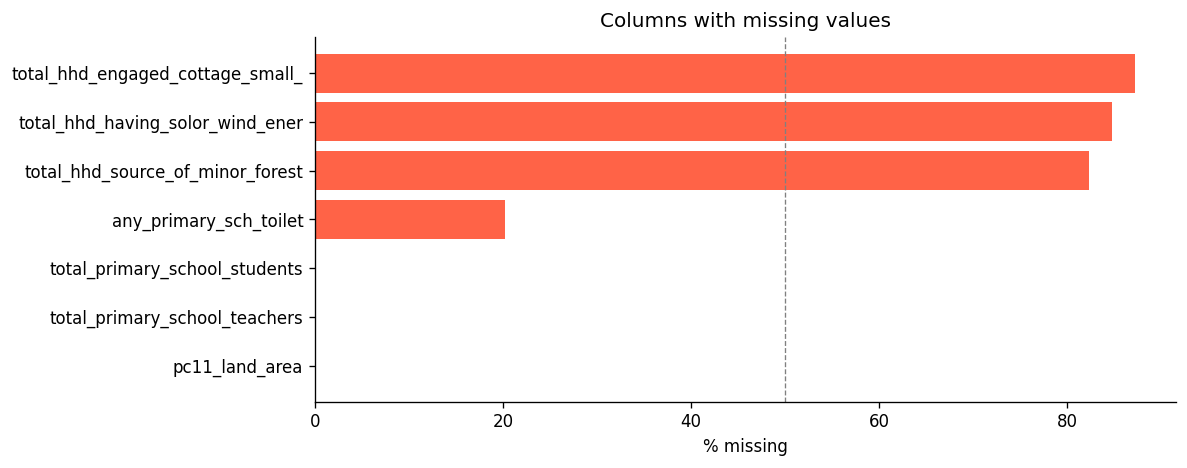

In [35]:
miss_pct = anty.isnull().mean().sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(miss_pct) * 0.3)))
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1] * 100, color="tomato", edgecolor="none")
ax.set_xlabel("% missing")
ax.set_title("Columns with missing values")
ax.axvline(50, color="grey", lw=0.8, linestyle="--")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_01_missing.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2  Demographics

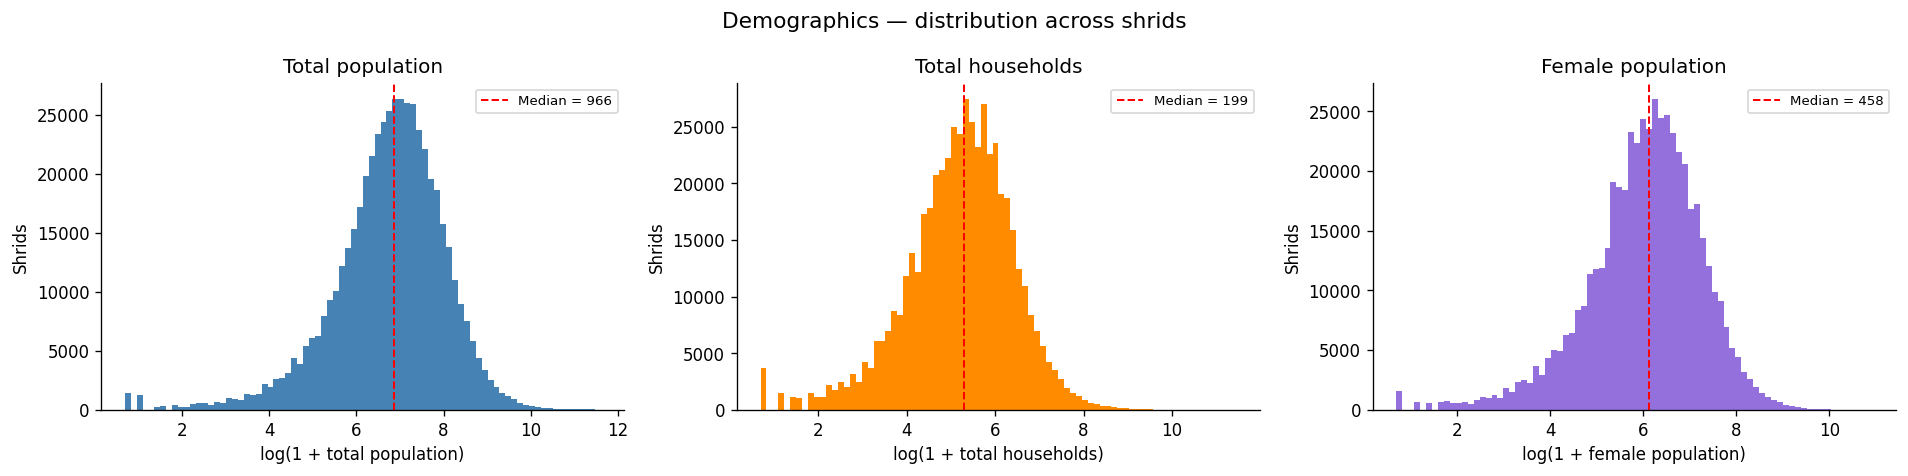

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color, label in [
    (axes[0], "total_population",  "steelblue",  "Total population"),
    (axes[1], "total_hhd",         "darkorange", "Total households"),
    (axes[2], "female_population", "mediumpurple","Female population"),
]:
    vals = anty[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log1p(vals), bins=80, color=color, edgecolor="none")
    ax.axvline(np.log1p(vals.median()), color="red", lw=1.2, linestyle="--",
               label=f"Median = {vals.median():.0f}")
    ax.set_xlabel(f"log(1 + {label.lower()})")
    ax.set_ylabel("Shrids")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("Demographics — distribution across shrids", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_02_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3  Agriculture — land use

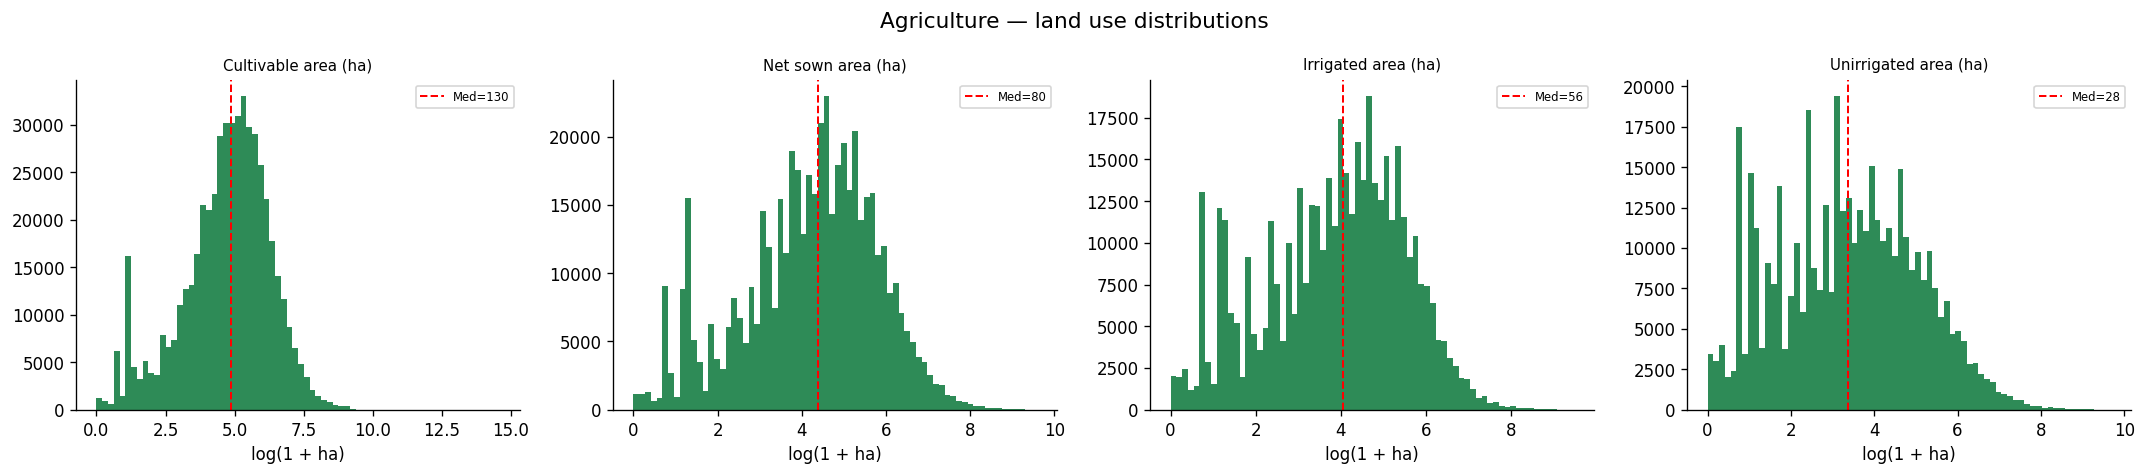

In [37]:
agri_cols = [
    ("total_cultivable_area_in_hac", "Cultivable area (ha)"),
    ("net_sown_area_in_hac",          "Net sown area (ha)"),
    ("area_irrigated_in_hac",         "Irrigated area (ha)"),
    ("total_unirrigated_land_area_in_h", "Unirrigated area (ha)"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (col, label) in zip(axes, agri_cols):
    vals = anty[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log1p(vals), bins=70, color="seagreen", edgecolor="none")
    ax.axvline(np.log1p(vals.median()), color="red", lw=1.2, linestyle="--",
               label=f"Med={vals.median():.0f}")
    ax.set_xlabel("log(1 + ha)")
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Agriculture — land use distributions", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_03_agriculture.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.4  Infrastructure access — binary indicators

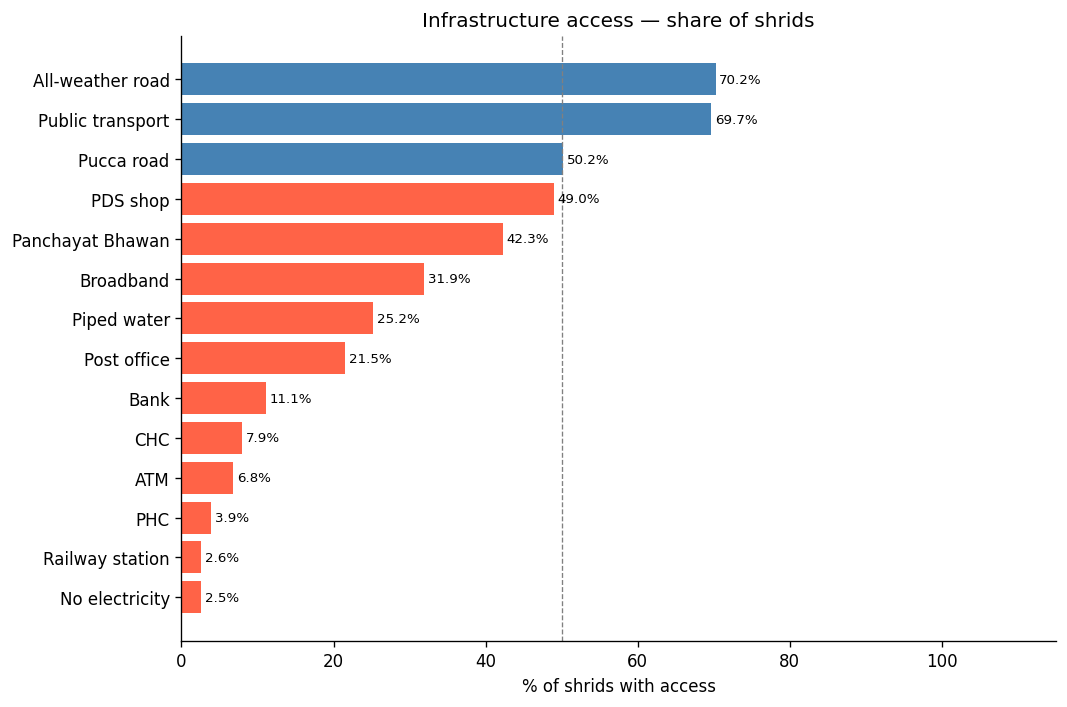

In [38]:
infra_cols = {
    "piped_water_fully_covered":      "Piped water",
    "is_village_connected_to_all_weat":"All-weather road",
    "public_transport":               "Public transport",
    "availability_of_railway_station":"Railway station",
    "is_broadband_available":         "Broadband",
    "is_pds_available":               "PDS shop",
    "is_bank_available":              "Bank",
    "is_atm_available":               "ATM",
    "is_post_office_available":       "Post office",
    "availability_of_panchayat_bhawan":"Panchayat Bhawan",
    "no_electricity":                 "No electricity",
    "internal_pucca_road":            "Pucca road",
    "phc":                            "PHC",
    "chc":                            "CHC",
}

shares = {label: anty[col].map(lambda x: 1 if str(x).strip() in ["1","Yes","yes","YES","1.0"] else
                               (0 if str(x).strip() in ["0","No","no","NO","0.0"] else np.nan)
          ).mean() for col, label in infra_cols.items()}
shares_s = pd.Series(shares).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(shares_s.index, shares_s.values * 100,
               color=["tomato" if v < 0.5 else "steelblue" for v in shares_s.values],
               edgecolor="none")
ax.axvline(50, color="grey", lw=0.8, linestyle="--")
for bar, val in zip(bars, shares_s.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=8)
ax.set_xlabel("% of shrids with access")
ax.set_title("Infrastructure access — share of shrids")
ax.set_xlim(0, 115)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_04_infrastructure.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.5  Education

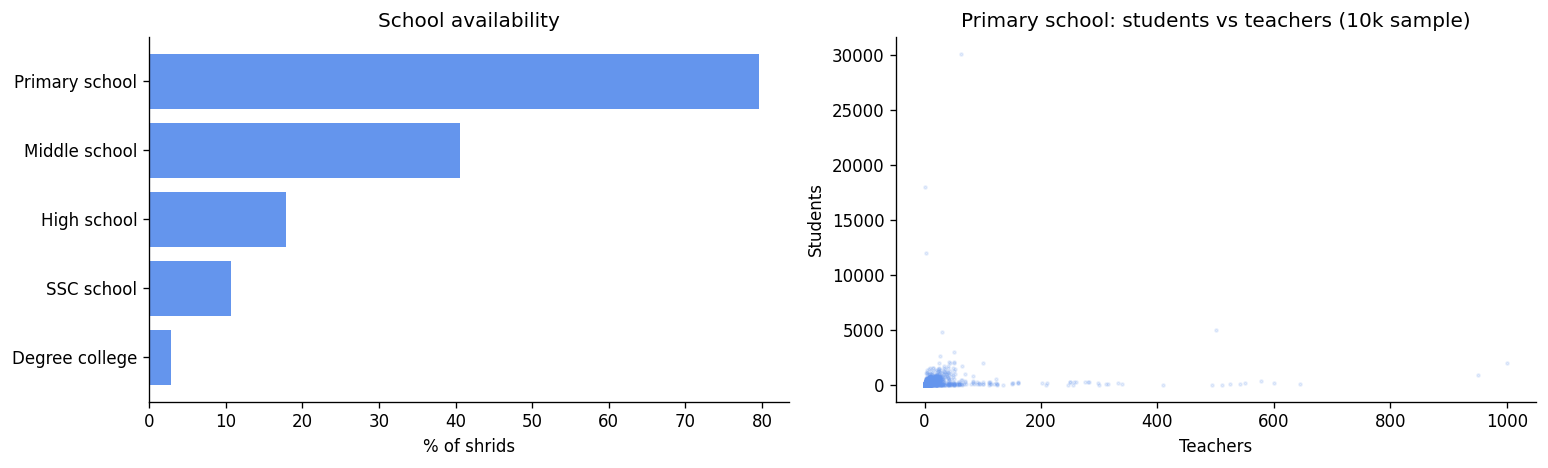

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# School availability shares
sch_cols = {
    "availability_of_primary_school": "Primary school",
    "availability_of_middle_school":  "Middle school",
    "availability_of_high_school":    "High school",
    "availability_of_ssc_school":     "SSC school",
    "availability_of_govt_degree_coll":"Degree college",
}
sch_shares = {label: (anty[col] == 1).mean() for col, label in sch_cols.items()}
sch_s = pd.Series(sch_shares).sort_values()
axes[0].barh(sch_s.index, sch_s.values * 100, color="cornflowerblue", edgecolor="none")
axes[0].set_xlabel("% of shrids")
axes[0].set_title("School availability")

# Students vs teachers scatter
samp_edu = anty[["total_primary_school_students","total_primary_school_teachers"]].dropna()
samp_edu = samp_edu[(samp_edu > 0).all(axis=1)].sample(min(10_000, len(samp_edu)), random_state=42)
axes[1].scatter(samp_edu["total_primary_school_teachers"],
                samp_edu["total_primary_school_students"],
                alpha=0.15, s=3, color="cornflowerblue")
axes[1].set_xlabel("Teachers")
axes[1].set_ylabel("Students")
axes[1].set_title("Primary school: students vs teachers (10k sample)")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_05_education.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.6  Health & nutrition

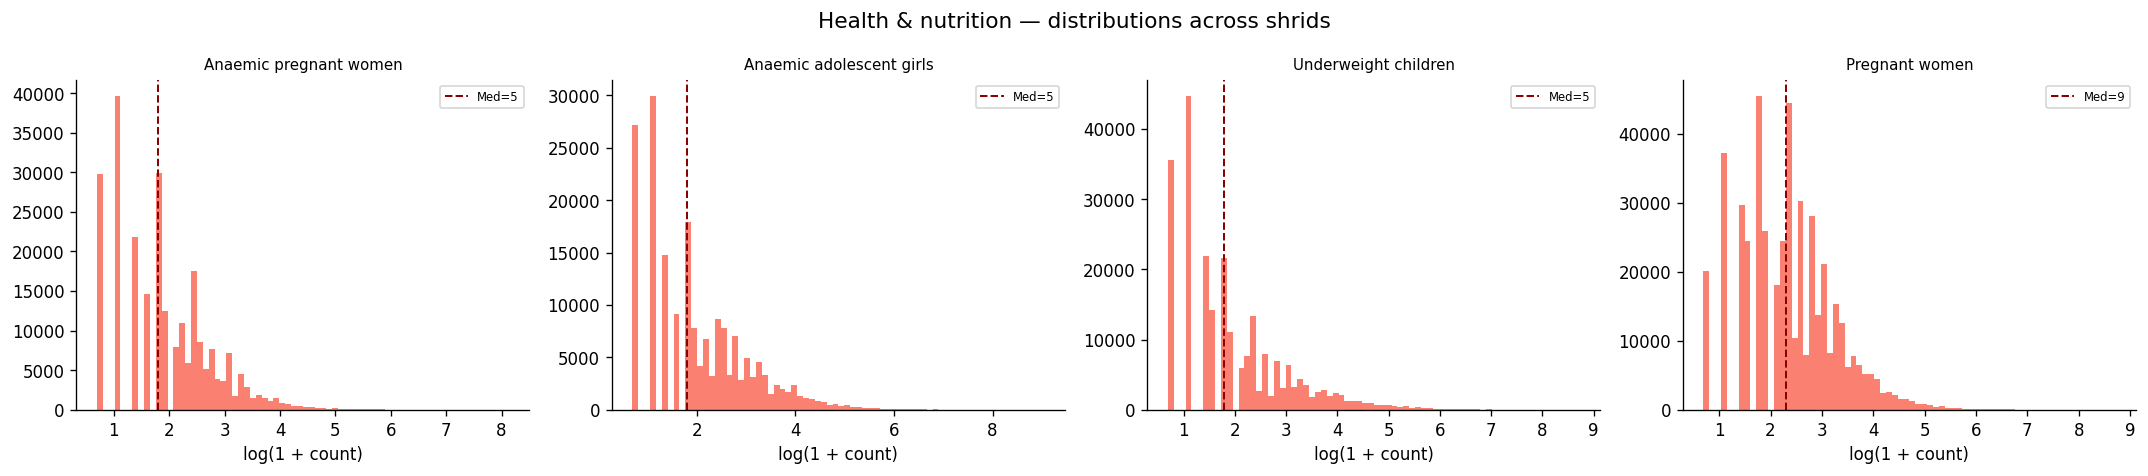

In [40]:
health_cols = [
    ("total_anemic_pregnant_women",     "Anaemic pregnant women"),
    ("total_anemic_adolescent_girls",   "Anaemic adolescent girls"),
    ("total_underweight_child_age_unde","Underweight children"),
    ("total_no_of_pregnant_women",      "Pregnant women"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (col, label) in zip(axes, health_cols):
    vals = anty[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log1p(vals), bins=70, color="salmon", edgecolor="none")
    ax.axvline(np.log1p(vals.median()), color="darkred", lw=1.2, linestyle="--",
               label=f"Med={vals.median():.0f}")
    ax.set_xlabel("log(1 + count)")
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Health & nutrition — distributions across shrids", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_06_health.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.7  Social welfare — SHGs, pensions, BPL cards

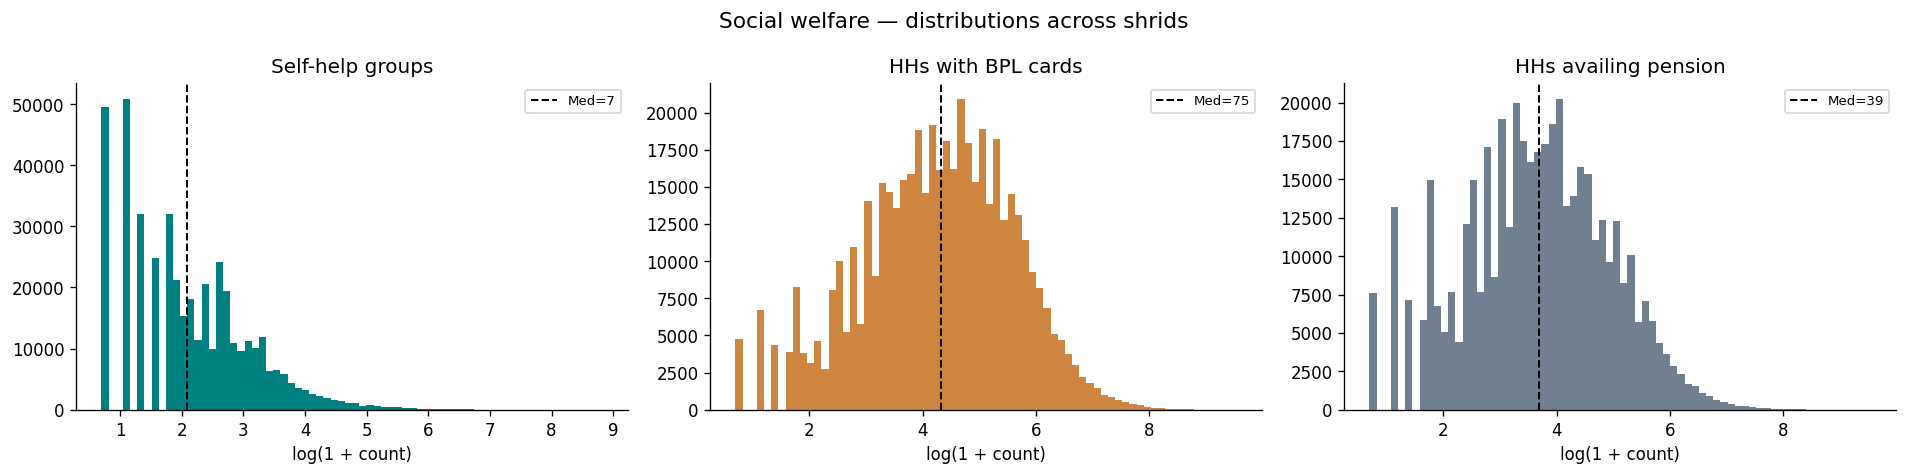

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color, label in [
    (axes[0], "total_shg",                      "teal",       "Self-help groups"),
    (axes[1], "total_hhd_having_bpl_cards",     "peru",       "HHs with BPL cards"),
    (axes[2], "total_hhd_availing_pension_under","slategrey", "HHs availing pension"),
]:
    vals = anty[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log1p(vals), bins=70, color=color, edgecolor="none")
    ax.axvline(np.log1p(vals.median()), color="black", lw=1.2, linestyle="--",
               label=f"Med={vals.median():.0f}")
    ax.set_xlabel("log(1 + count)")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("Social welfare — distributions across shrids", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_07_welfare.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.8  Correlation heatmap — key numeric variables

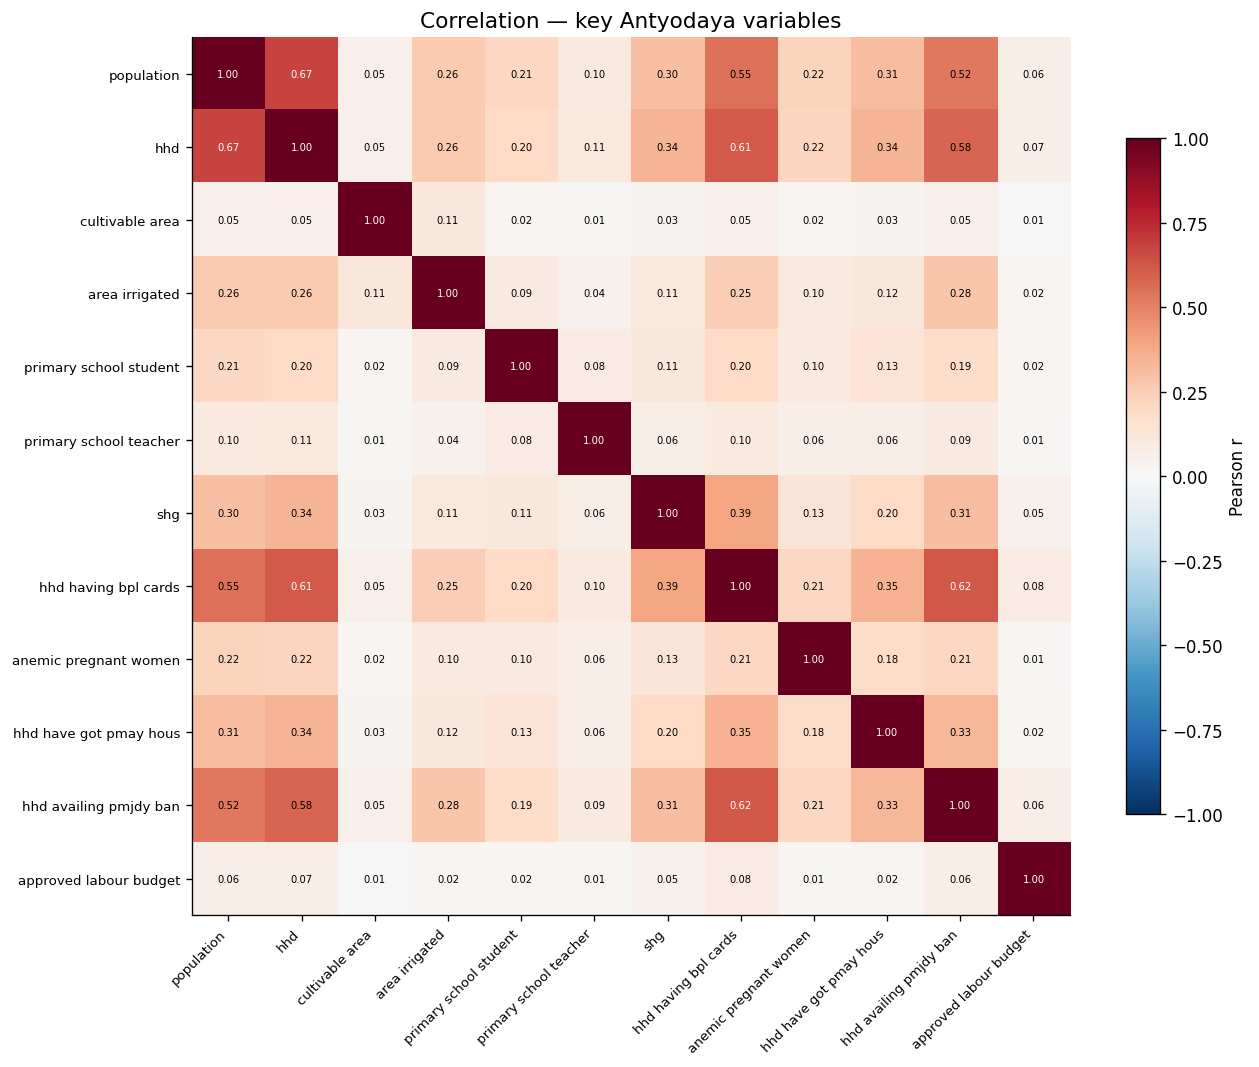

In [42]:
corr_cols = [
    "total_population", "total_hhd", "total_cultivable_area_in_hac",
    "area_irrigated_in_hac", "total_primary_school_students",
    "total_primary_school_teachers", "total_shg", "total_hhd_having_bpl_cards",
    "total_anemic_pregnant_women", "total_hhd_have_got_pmay_house",
    "total_hhd_availing_pmjdy_bank_ac", "total_approved_labour_budget_for",
]

corr = anty[corr_cols].corr()
short = [c.replace("total_","").replace("_in_hac","").replace("_"," ")[:22] for c in corr_cols]
corr.index = corr.columns = short

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(short)))
ax.set_yticks(range(len(short)))
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(short, fontsize=8)
for i in range(len(short)):
    for j in range(len(short)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(corr.iloc[i,j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="Pearson r", fraction=0.03)
ax.set_title("Correlation — key Antyodaya variables", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "anty_08_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.9  Summary statistics

In [43]:
summary_cols = [
    "total_population","total_hhd","total_cultivable_area_in_hac",
    "area_irrigated_in_hac","total_shg","total_hhd_having_bpl_cards",
    "total_primary_school_students","total_anemic_pregnant_women",
]
anty[summary_cols].describe().round(1)

,total_population,total_hhd,total_cultivable_area_in_hac,area_irrigated_in_hac,total_shg,total_hhd_having_bpl_cards,total_primary_school_students,total_anemic_pregnant_women
count,521223.0,521223.0,521223.0,521223.0,521223.0,521223.0,520760.0,521223.0
mean,1645.0,338.1,300.2,115.8,12.2,145.8,102.9,4.6
std,2648.9,559.1,3076.0,252.8,36.7,252.0,417.4,15.0
min,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,440.0,90.0,46.0,2.5,1.0,23.0,15.0,0.0
50%,966.0,199.0,130.4,37.2,5.0,67.0,55.0,0.0
75%,1947.0,400.0,320.0,128.3,12.0,174.0,125.0,5.0
max,108883.0,94678.0,2180218.0,13000.0,6852.0,14000.0,90964.0,3400.0
